In [1]:
import mpmath as mp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec

In [2]:
mp.mp.dps = 30

def set_precision(dps: int):
    mp.mp.dps = dps


def mpmat_zeros(n: int, m: int = None):
    if m is None:
        m = n
    return mp.matrix(n, m)


In [ ]:
def identity(n: int):
    I = mp.matrix(n, n)
    for i in range(n):
        I[i, i] = mp.mpf("1")
    return I


def hermitize(H: mp.matrix):
    return (H + H.transpose_conj()) / mp.mpf("2")


def submatrix(A: mp.matrix, rows, cols):
    out = mp.matrix(len(rows), len(cols))
    for i, r in enumerate(rows):
        for j, c in enumerate(cols):
            out[i, j] = A[r, c]
    return out


def diag_from_list(vals):
    n = len(vals)
    M = mp.matrix(n, n)
    for i, v in enumerate(vals):
        M[i, i] = v
    return M


def matrix_to_nested_float_lists(M: mp.matrix):
    return [[float(mp.re(M[i, j])) for j in range(M.cols)] for i in range(M.rows)]


def to_float_list(xs):
    return [float(x) for x in xs]


def col(results, idx):
    return [row[idx] for row in results]


def min_positive(xs):
    positives = [x for x in xs if x > 0]
    return min(positives) if positives else None


def sorted_unique(xs):
    return sorted(set(xs), key=lambda z: float(z))


def reshape_flat(flat, nrows, ncols):
    if len(flat) != nrows * ncols:
        raise ValueError(f"Cannot reshape list of length {len(flat)} into ({nrows}, {ncols})")
    return [flat[r * ncols:(r + 1) * ncols] for r in range(nrows)]


def clamp_nonpositive_to_min_positive(y):
    y2 = list(y)
    mp_min = min_positive(y2)
    if mp_min is None:
        return y2
    return [mp_min if val <= 0 else val for val in y2]


def make_real_symmetric(H: mp.matrix, tol=None, verbose=False):
    Hh = hermitize(H)
    n = Hh.rows

    if tol is None:
        # tolerance tied to working precision
        tol = mp.mpf(10) ** (-(mp.mp.dps - 20))

    Hr = mp.matrix(n, n)

    max_im = mp.mpf("0")
    max_herm_violation = mp.mpf("0")

    for i in range(n):
        for j in range(n):
            hij = Hh[i, j]

            im_abs = abs(mp.im(hij))
            if im_abs > max_im:
                max_im = im_abs

            herm_violation = abs(hij - mp.conj(Hh[j, i]))
            if herm_violation > max_herm_violation:
                max_herm_violation = herm_violation

            Hr[i, j] = mp.re(hij)

    if verbose:
        print(f"max imaginary part      = {max_im}")
        print(f"max Hermitian violation = {max_herm_violation}")
        print(f"tolerance               = {tol}")

    if max_im > tol:
        raise ValueError(
            f"Matrix is not sufficiently real for mp.eigsy: "
            f"max imaginary part = {max_im}, tolerance = {tol}"
        )

    return Hr


def matrix_diagnostics(H: mp.matrix):
    Hh = hermitize(H)
    n = Hh.rows

    max_im = mp.mpf("0")
    max_herm_violation = mp.mpf("0")

    for i in range(n):
        for j in range(n):
            max_im = max(max_im, abs(mp.im(Hh[i, j])))
            max_herm_violation = max(
                max_herm_violation,
                abs(Hh[i, j] - mp.conj(Hh[j, i]))
            )

    print("max imaginary part      =", max_im)
    print("max Hermitian violation =", max_herm_violation)

In [4]:
def ladder_ops(N: int):
    a = mp.matrix(N, N)
    adag = mp.matrix(N, N)

    for n in range(1, N):
        a[n - 1, n] = mp.sqrt(n)

    for n in range(0, N - 1):
        adag[n + 1, n] = mp.sqrt(n + 1)

    return a, adag



In [5]:
def ho_operators(N: int, omega):
    omega = mp.mpf(omega)
    a, adag = ladder_ops(N)
    phi = (a + adag) / mp.sqrt(2 * omega)
    pi = 1j * mp.sqrt(omega / 2) * (adag - a)
    return phi, pi, a, adag


In [6]:
def build_H0(N: int, omega):
    omega = mp.mpf(omega)
    phi, pi, _, _ = ho_operators(N, omega)
    return mp.mpf("0.5") * (pi * pi) + mp.mpf("0.5") * omega**2 * (phi * phi)


def build_V(N: int, omega, lam):
    omega = mp.mpf(omega)
    lam = mp.mpf(lam)
    phi, _, _, _ = ho_operators(N, omega)
    phi2 = phi * phi
    phi4 = phi2 * phi2
    V_mass = mp.mpf("0.5") * (mp.mpf("1.0") - omega**2) * phi2
    V_x4 = (lam / mp.mpf("24.0")) * phi4
    return V_mass + V_x4


def build_full_H(N: int, omega, lam):
    return build_H0(N, omega) + build_V(N, omega, lam)


In [7]:
def indices_below_Emax(omega, Emax, N_uv: int):
    omega = mp.mpf(omega)
    Emax = mp.mpf(Emax)

    n = list(range(N_uv))
    En = [omega * (k + mp.mpf("0.5")) for k in n]
    P = [k for k, E in enumerate(En) if E <= Emax]
    Q = [k for k, E in enumerate(En) if E > Emax]
    return P, Q, En

In [8]:
def naive_Heff(N_uv: int, omega, lam, Emax, hermitianize=True):
    H0 = build_H0(N_uv, omega)
    V = build_V(N_uv, omega, lam)

    P, Q, En = indices_below_Emax(omega, Emax, N_uv)
    nP = len(P)
    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")

    H0_PP = submatrix(H0, P, P)
    V_PP = submatrix(V, P, P)

    Heff = H0_PP + V_PP
    if hermitianize:
        Heff = hermitize(Heff)

    return Heff, P, Q, H0, V


def htet_Heff_O_V2(N_uv: int, omega, lam, Emax, hermitianize=True):
    H0 = build_H0(N_uv, omega)
    V = build_V(N_uv, omega, lam)

    P, Q, En = indices_below_Emax(omega, Emax, N_uv)
    nP = len(P)
    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")

    H0_PP = submatrix(H0, P, P)
    V_PP = submatrix(V, P, P)
    V_PQ = submatrix(V, P, Q)
    V_QP = submatrix(V, Q, P)

    Heff = H0_PP + V_PP
    H2 = mp.matrix(nP, nP)

    EP = [En[i] for i in P]
    EQ = [En[i] for i in Q]

    for f in range(nP):
        Ef = EP[f]
        inv = [1 / (Ef - Eqa) for Eqa in EQ]
        for i in range(nP):
            s = mp.mpc("0")
            for a in range(len(Q)):
                s += V_PQ[f, a] * inv[a] * V_QP[a, i]
            H2[f, i] = s

    Heff = Heff + H2
    if hermitianize:
        Heff = hermitize(Heff)

    return Heff, P, Q, H0, V


def htet_Heff_O_V3(N_uv: int, omega, lam, Emax, hermitianize=True):
    Heff2, P, Q, H0, V = htet_Heff_O_V2(N_uv, omega, lam, Emax)
    _, _, En = indices_below_Emax(omega, Emax, N_uv)

    nP = len(P)
    nQ = len(Q)

    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")
    if nQ == 0:
        return Heff2, P, Q, H0, V

    V_PP = submatrix(V, P, P)
    V_PQ = submatrix(V, P, Q)
    V_QP = submatrix(V, Q, P)
    V_QQ = submatrix(V, Q, Q)

    H3 = mp.matrix(nP, nP)

    EP = [En[i] for i in P]
    EQ = [En[i] for i in Q]

    A = mp.matrix(nP, nQ)
    for a in range(nP):
        for b in range(nQ):
            A[a, b] = V_PQ[a, b] / (EP[a] - EQ[b])

    for f in range(nP):
        Ef = EP[f]
        inv_f = [1 / (Ef - Eqa) for Eqa in EQ]

        # first term
        tmp_b = [mp.mpc("0") for _ in range(nQ)]
        for b in range(nQ):
            s = mp.mpc("0")
            for a in range(nQ):
                s += V_PQ[f, a] * inv_f[a] * V_QQ[a, b]
            tmp_b[b] = s

        term1_row = [mp.mpc("0") for _ in range(nP)]
        for i in range(nP):
            s = mp.mpc("0")
            for b in range(nQ):
                s += tmp_b[b] * inv_f[b] * V_QP[b, i]
            term1_row[i] = s

        # second term
        s_b = [mp.mpc("0") for _ in range(nQ)]
        for b in range(nQ):
            s = mp.mpc("0")
            for a in range(nP):
                s += V_PP[f, a] * A[a, b]
            s_b[b] = s

        term2_row = [mp.mpc("0") for _ in range(nP)]
        for i in range(nP):
            s = mp.mpc("0")
            for b in range(nQ):
                s += s_b[b] * inv_f[b] * V_QP[b, i]
            term2_row[i] = s

        for i in range(nP):
            H3[f, i] = term1_row[i] - term2_row[i]

    Heff3 = Heff2 + H3
    if hermitianize:
        Heff = hermitize(Heff)

    return Heff3, P, Q, H0, V

In [9]:
def ground_state_energy_from_matrix(
    H,
    hermitian=True,
    tol=None,
    verbose=False,
    imag_tol=mp.mpf("1e-20"),
    select="smallest_real"
):
    if hermitian:
        Hr = make_real_symmetric(H, tol=tol, verbose=verbose)
        evals, _ = mp.eigsy(Hr)
        evals = list(evals)
        return evals[0], evals
    else:
        return ground_state_energy_nonhermitian(
            H,
            imag_tol=imag_tol,
            select=select
        )



In [10]:
def ground_state_energy_nonhermitian(
    H,
    imag_tol=mp.mpf("1e-20"),
    select="smallest_real"
):
    evals, evec_r = mp.eig(H, left=False, right=True)
    evals = list(evals)

    # keep finite eigenvalues
    evals = [ev for ev in evals if mp.isfinite(ev)]

    if not evals:
        raise ValueError("No finite eigenvalues found.")

    if select == "smallest_real":
        # primary rule: choose the eigenvalue with smallest real part
        # among those with acceptably small imaginary parts if possible
        nearly_real = [ev for ev in evals if abs(mp.im(ev)) <= imag_tol]

        if nearly_real:
            chosen = min(nearly_real, key=lambda z: mp.re(z))
        else:
            # fallback: choose the one with smallest real part anyway
            chosen = min(evals, key=lambda z: mp.re(z))

    elif select == "min_abs_imag_then_real":
        chosen = min(evals, key=lambda z: (abs(mp.im(z)), mp.re(z)))

    else:
        raise ValueError(f"Unknown selection rule: {select}")

    return chosen, evals

In [ ]:
def acceptable_eigenvalue(ev, rel_imag_tol=mp.mpf("1e-10"), abs_imag_tol=mp.mpf("1e-20")):
    return abs(mp.im(ev)) <= max(abs_imag_tol, rel_imag_tol * max(1, abs(mp.re(ev))))

def run_energy_scan(
    heff: str,
    omega=1.0,
    lam=1.0,
    Emax_list=(6.0, 7.0, 8.0, 9.0, 10.0),
    Known_E=1.0,
    print_table=True,
    hermitianize=True,
    imag_tol=mp.mpf("1e-20")
):
    results = []

    if print_table:
        print(f"omega={omega}  lambda={lam}")
        print("Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error (rel to known)")
        print("-" * 90)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    add_dict = {
        "H1": 8,
        "H2": 12,
        "H3": 16
    }

    Known_E = mp.mpf(Known_E)

    for Emax in Emax_list:
        Emax_mp = mp.mpf(Emax)
        N_uv = int(mp.floor(Emax_mp)) + add_dict[heff]

        H_full = build_full_H(N_uv, omega, lam)
        P, Q, En = indices_below_Emax(omega, Emax_mp, N_uv)
        nP = len(P)

        H_raw = submatrix(H_full, P, P)
        E0_raw, _ = ground_state_energy_from_matrix(H_raw)

        H_htet, _, _, _, _ = Heff_dict[heff](N_uv, omega, lam, Emax_mp, hermitianize=hermitianize)
        E0_htet, _ = ground_state_energy_from_matrix(H_htet, hermitian=hermitianize, imag_tol=imag_tol)

        E_phys = mp.re(E0_htet)
        diff = Known_E - E_phys
        percentage_error = 100 * abs(diff / Known_E)
        imag_part = abs(mp.im(E0_htet))

        if not acceptable_eigenvalue(E0_htet):
            percentage_error = mp.nan

        row = [Emax_mp, nP, E0_raw, E0_htet, percentage_error, diff, imag_part]
        results.append(row)

        if print_table:
            print(
                f"{float(Emax_mp):6.2f} | {nP:6d} | "
                f"{mp.nstr(mp.re(E0_raw), 12)},{mp.nstr(mp.im(E0_raw), 3)} | "
                f"{mp.nstr(mp.re(E0_htet), 12)},{mp.nstr(mp.im(E0_htet), 3)} | "
                f"{mp.nstr(percentage_error, 6)}"
            )

    results = [r for r in results if r[4] != 0]
    return results


def run_omega_scan(
    heff: str,
    omega_list=(1.0, 2.0, 3.0, 4.0, 5.0),
    lam=1.0,
    N_uv=200,
    Emax=50.0,
    Known_E=1.0,
    print_table=True,
    hermitianize=True,
    imag_tol=mp.mpf("1e-20")
):
    results = []

    if print_table:
        print(f"lambda(Cohen)={lam}")
        print("Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error | omega")
        print("-" * 90)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    Emax = mp.mpf(Emax)
    Known_E = mp.mpf(Known_E)

    for omega in omega_list:
        omega_mp = mp.mpf(omega)


        H_full = build_full_H(N_uv, omega_mp, lam)
        P, Q, En = indices_below_Emax(omega_mp, Emax, N_uv)
        nP = len(P)

        H_raw = submatrix(H_full, P, P)
        E0_raw, _ = ground_state_energy_from_matrix(H_raw)

        H_htet, _, _, _, _ = Heff_dict[heff](N_uv, omega_mp, lam, Emax, hermitianize=hermitianize)
        E0_htet, _ = ground_state_energy_from_matrix(H_htet, hermitian=hermitianize, imag_tol=imag_tol)

        E_phys = mp.re(E0_htet)
        diff = Known_E - E_phys
        percentage_error = 100 * abs(diff / Known_E)
        imag_part = abs(mp.im(E0_htet))

        if not acceptable_eigenvalue(E0_htet):
            percentage_error = mp.nan

        row = [Emax, nP, E0_raw, E0_htet, percentage_error, omega_mp, diff]
        results.append(row)

        if print_table:
            print(
                f"{float(Emax):6.2f} | {nP:6d} | "
                f"{mp.nstr(mp.re(E0_raw), 12)},{mp.nstr(mp.im(E0_raw), 3)} | "
                f"{mp.nstr(mp.re(E0_htet), 12)},{mp.nstr(mp.im(E0_htet), 3)} | "
                f"{mp.nstr(percentage_error, 6)} | {mp.nstr(omega_mp, 8)}"
            )

    results = [r for r in results if r[4] != 0]
    return results


def run_emax_omega_scan(
    heff: str,
    omega_list,
    lam=1.0,
    Emax_list=(6.0, 7.0, 8.0, 9.0, 10.0),
    Known_E=1.0,
    print_table=True,
    hermitianize=True,
    imag_tol=mp.mpf("1e-20")
):
    results = []

    if print_table:
        print(f"lambda(Cohen)={lam}")
        print("Emax | omega | percentage error")
        print("-" * 70)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    add_dict = {"H1": 8, "H2": 12, "H3": 16}
    Known_E = mp.mpf(Known_E)

    for Emax in Emax_list:
        Emax_mp = mp.mpf(Emax)
        for omega in omega_list:
            omega_mp = mp.mpf(omega)
            N_uv = int(mp.floor(Emax_mp)) + add_dict[heff]

            H_full = build_full_H(N_uv, omega_mp, lam)
            P, Q, En = indices_below_Emax(omega_mp, Emax_mp, N_uv)

            if len(P) == 0:
                continue

            H_raw = submatrix(H_full, P, P)
            E0_raw, _ = ground_state_energy_from_matrix(H_raw)

            H_htet, _, _, _, _ = Heff_dict[heff](N_uv, omega_mp, lam, Emax_mp, hermitianize=hermitianize)
            E0_htet, _ = ground_state_energy_from_matrix(H_htet, hermitian=hermitianize, imag_tol=imag_tol)

            E_phys = mp.re(E0_htet)
            diff = Known_E - E_phys
            percentage_error = 100 * abs(diff / Known_E)
            imag_part = abs(mp.im(E0_htet))

            if not acceptable_eigenvalue(E0_htet):
                percentage_error = mp.nan

            results.append([Emax_mp, omega_mp, percentage_error, diff])

            if print_table:
                print(f"{float(Emax_mp):6.2f} | {float(omega_mp):8.4f} | {mp.nstr(percentage_error, 6)}")

    errors = [r[2] for r in results]
    nonzero_errors = [e for e in errors if e > 0]

    if nonzero_errors:
        min_nonzero = min(nonzero_errors)
        for r in results:
            if r[2] == 0:
                r[2] = min_nonzero

    return results

In [36]:
E0 = mp.mpf("0.52773612731410831269035109114701621561393954399308")
nQ_list = (2, 3, 4, 5, 6, 7, 8, 9)

In [39]:
omega_list = [mp.mpf("0.5") + mp.mpf(i) * mp.mpf("0.05") for i in range(10)]
nQ = 3
Emax = 40
H_list = ["H1", "H2", "H3"]
Emax_list = [8, 16, 32]
fontsize = 12

In [ ]:
N_uv1 = int(Emax) + 8
N_uv2 = int(Emax) + 12
N_uv3 = int(Emax) + 16

O_results_H1 = run_omega_scan(
    heff="H1",
    omega_list=omega_list,
    lam=1.0,
    N_uv=N_uv1,
    Emax=Emax,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)

O_results_H2 = run_omega_scan(
    heff="H2",
    omega_list=omega_list,
    lam=1.0,
    N_uv=N_uv2,
    Emax=Emax,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)

O_results_H3 = run_omega_scan(
    heff="H3",
    omega_list=omega_list,
    lam=1.0,
    N_uv=N_uv3,
    Emax=Emax,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)




lambda(Cohen)=1.0
Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error | omega
------------------------------------------------------------------------------------------
 40.00 |     80 | 0.527736127314,0.0 | 0.527736127314,0.0 | 2.15418e-20 | 0.5
 40.00 |     73 | 0.527736127314,0.0 | 0.527736127314,0.0 | 1.31561e-20 | 0.55
 40.00 |     67 | 0.527736127314,0.0 | 0.527736127314,0.0 | 7.80279e-21 | 0.6
 40.00 |     62 | 0.527736127314,0.0 | 0.527736127314,0.0 | 6.13551e-21 | 0.65
 40.00 |     57 | 0.527736127314,0.0 | 0.527736127314,0.0 | 1.12296e-20 | 0.7
 40.00 |     53 | 0.527736127314,0.0 | 0.527736127314,0.0 | 2.38466e-20 | 0.75
 40.00 |     50 | 0.527736127314,0.0 | 0.527736127314,0.0 | 5.12198e-20 | 0.8
 40.00 |     47 | 0.527736127314,0.0 | 0.527736127314,0.0 | 7.01184e-20 | 0.85
 40.00 |     44 | 0.527736127314,0.0 | 0.527736127314,0.0 | 2.21215e-19 | 0.9
 40.00 |     42 | 0.527736127314,0.0 | 0.527736127314,0.0 | 3.15573e-19 | 0.95
lambda(Cohen)=1.0
Emax | dim(P

KeyboardInterrupt: 

best error for H3 is 2.13159363217892508919662627521e-15
best error for H2 is 1.54574143149599505993611726702e-15
best error for H1 is 2.96452220715356344485481548939e-19


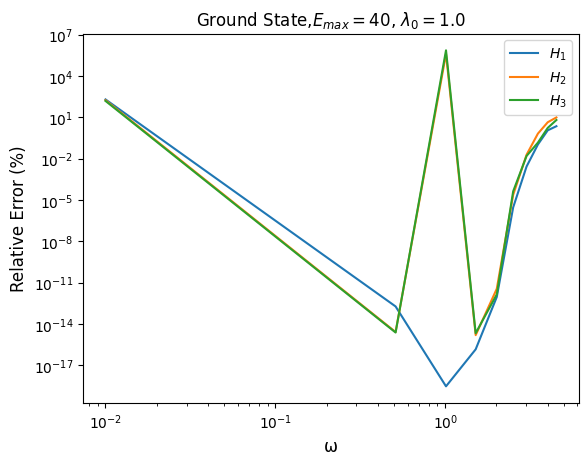

In [ ]:
print(f"best error for H3 is {min(col(O_results_H3, 4))}")
print(f"best error for H2 is {min(col(O_results_H2, 4))}")
print(f"best error for H1 is {min(col(O_results_H1, 4))}")

plt.loglog(to_float_list(col(O_results_H1, 5)), to_float_list(col(O_results_H1, 4)), label=r"$H_1$")
plt.loglog(to_float_list(col(O_results_H2, 5)), to_float_list(col(O_results_H2, 4)), label=r"$H_2$")
plt.loglog(to_float_list(col(O_results_H3, 5)), to_float_list(col(O_results_H3, 4)), label=r"$H_3$")
plt.xlabel("ω", fontsize=fontsize)
plt.ylabel("Relative Error (%)", fontsize=fontsize)
plt.title(r"Ground State,$E_{max} = 40$, $\lambda_0 = 1.0$")
plt.legend()
plt.show()

In [ ]:
Emax_List = [mp.mpf("1") + i *10 for i in range(9)]
omega = mp.mpf("0.6")

E_results_H1 = run_energy_scan(
    heff="H1",
    omega=omega,
    lam=1.0,
    Emax_list=Emax_List,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)

E_results_H2 = run_energy_scan(
    heff="H2",
    omega=omega,
    lam=1.0,
    Emax_list=Emax_List,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)

E_results_H3 = run_energy_scan(
    heff="H3",
    omega=omega,
    lam=1.0,
    Emax_list=Emax_List,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)

H3_errors = col(E_results_H3, 4)
H2_errors = col(E_results_H2, 4)
H1_errors = col(E_results_H1, 4)

H3_argmin = min(range(len(H3_errors)), key=lambda i: H3_errors[i])
H2_argmin = min(range(len(H2_errors)), key=lambda i: H2_errors[i])
H1_argmin = min(range(len(H1_errors)), key=lambda i: H1_errors[i])

print(f"best error for H3 is {mp.nstr(H3_errors[H3_argmin], 20)} at {E_results_H3[H3_argmin][0]}")
print(f"best error for H2 is {mp.nstr(H2_errors[H2_argmin], 20)} at {E_results_H2[H2_argmin][0]}")
print(f"best error for H1 is {mp.nstr(H1_errors[H1_argmin], 20)} at {E_results_H1[H1_argmin][0]}")



omega=0.6  lambda=1.0
Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error (rel to known)
------------------------------------------------------------------------------------------
  1.00 |      2 | 0.653472222222,0.0 | 0.653472222222,0.0 | 23.8256
 11.00 |     18 | 0.527736132188,0.0 | 0.527736132188,0.0 | 9.23534e-7
 21.00 |     29 | 0.527736127317,0.0 | 0.527736127317,0.0 | 5.63957e-10
 31.00 |     39 | 0.527736127314,0.0 | 0.527736127314,0.0 | 9.91687e-14
 41.00 |     49 | 0.527736127314,0.0 | 0.527736127314,0.0 | 1.75825e-15
 51.00 |     59 | 0.527736127314,0.0 | 0.527736127314,0.0 | 6.06156e-18
 61.00 |     69 | 0.527736127314,0.0 | 0.527736127314,0.0 | 3.00667e-21
 71.00 |     79 | 0.527736127314,0.0 | 0.527736127314,0.0 | 4.57797e-22
 81.00 |     89 | 0.527736127314,0.0 | 0.527736127314,0.0 | 4.95111e-22
omega=0.6  lambda=1.0
Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error (rel to known)
--------------------------------------------------------

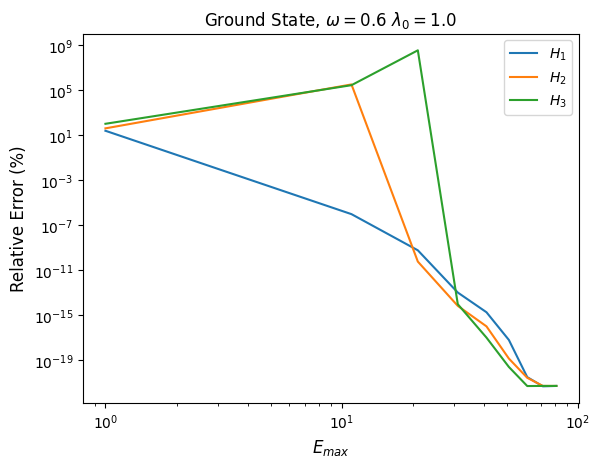

In [ ]:
plt.loglog(to_float_list(col(E_results_H1, 0)), to_float_list(col(E_results_H1, 4)), label=r"$H_1$")
plt.loglog(to_float_list(col(E_results_H2, 0)), to_float_list(col(E_results_H2, 4)), label=r"$H_2$")
plt.loglog(to_float_list(col(E_results_H3, 0)), to_float_list(col(E_results_H3, 4)), label=r"$H_3$")

plt.xlabel(r"$E_{max}$", fontsize=fontsize)
plt.ylabel("Relative Error (%)", fontsize=fontsize)
plt.title(r"Ground State, $\omega = 0.6$ $\lambda_0 = 1.0$")
plt.legend()
plt.show()

lambda(Cohen)=1.0
Emax | omega | percentage error
----------------------------------------------------------------------
  1.00 |   0.3000 | 41.639
  1.00 |   0.8000 | 6.3653
  1.00 |   1.3000 | 1.52779
  1.00 |   1.8000 | 13.4154
 21.00 |   0.3000 | 8.46268e-5
 21.00 |   0.8000 | 3.0047e-11
 21.00 |   1.3000 | 5.43882e-10
 21.00 |   1.8000 | 1.6411e-7
 21.00 |   2.3000 | 0.00247648
 41.00 |   0.3000 | 1.7253e-8
 41.00 |   0.8000 | 2.05796e-21
 41.00 |   1.3000 | 9.47934e-19
 41.00 |   1.8000 | 6.8277e-16
 41.00 |   2.3000 | 4.21001e-11
 61.00 |   0.3000 | 2.87748e-12
 61.00 |   0.8000 | 4.94876e-22
 61.00 |   1.3000 | 4.94885e-22
 61.00 |   1.8000 | 4.4811e-22
 61.00 |   2.3000 | 1.87128e-17
 81.00 |   0.3000 | 9.95397e-15
 81.00 |   0.8000 | 4.94901e-22
 81.00 |   1.3000 | 4.94881e-22
 81.00 |   1.8000 | 4.94894e-22
 81.00 |   2.3000 | 4.67619e-22

H1: missing 1 grid points
First few missing points:
  Emax=1.0, omega=2.3
H1:
Minimum Percentage error = 4.48109941458674368883500726033e

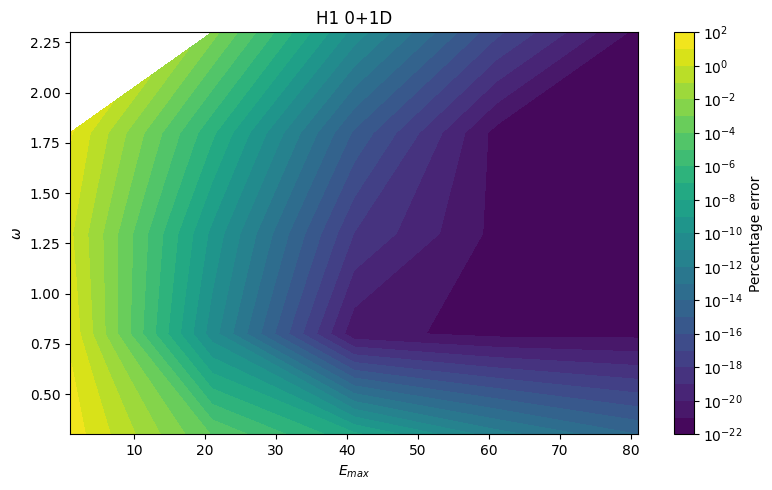

lambda(Cohen)=1.0
Emax | omega | percentage error
----------------------------------------------------------------------
  1.00 |   0.3000 | 20607.3
  1.00 |   0.8000 | 4.47229
  1.00 |   1.3000 | 0.159336
  1.00 |   1.8000 | 4.44399
 21.00 |   0.3000 | 9.08738e-6
 21.00 |   0.8000 | 277049.0
 21.00 |   1.3000 | 3.081e-9
 21.00 |   1.8000 | 4.9017e-7
 21.00 |   2.3000 | 0.00833091
 41.00 |   0.3000 | 4.35841e-9
 41.00 |   0.8000 | 3.52101e+6
 41.00 |   1.3000 | 23390.9
 41.00 |   1.8000 | 3.11363e-15
 41.00 |   2.3000 | 1.14476e-9
 61.00 |   0.3000 | 3.28897e-12
 61.00 |   0.8000 | 4.94921e-22
 61.00 |   1.3000 | 164203.0
 61.00 |   1.8000 | 1.23023e-21
 61.00 |   2.3000 | 2.01142e-16
 81.00 |   0.3000 | 6.59567e-16
 81.00 |   0.8000 | 4.94862e-22
 81.00 |   1.3000 | 562324.0
 81.00 |   1.8000 | 4.94898e-22
 81.00 |   2.3000 | 6.18632e-22

H2: missing 1 grid points
First few missing points:
  Emax=1.0, omega=2.3
H2:
Minimum Percentage error = 4.94862445823726678822216160693e-22
Occurs 

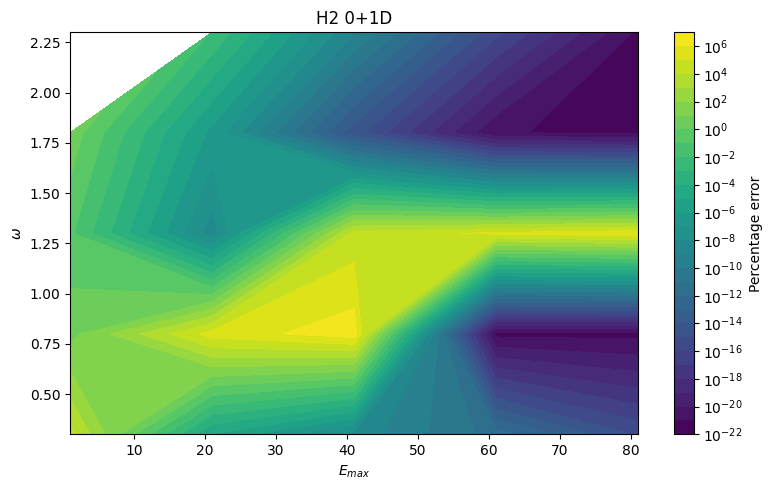

lambda(Cohen)=1.0
Emax | omega | percentage error
----------------------------------------------------------------------
  1.00 |   0.3000 | 193.795
  1.00 |   0.8000 | 4.70473
  1.00 |   1.3000 | 0.017071
  1.00 |   1.8000 | 1.71895
 21.00 |   0.3000 | 6.44561e-7
 21.00 |   0.8000 | 295194.0
 21.00 |   1.3000 | 1.99908e-9
 21.00 |   1.8000 | 2.03294e-7
 21.00 |   2.3000 | 0.00441604
 41.00 |   0.3000 | 2.56919e-10
 41.00 |   0.8000 | 2.6022e+7
 41.00 |   1.3000 | 3443.23
 41.00 |   1.8000 | 5.69472e-15
 41.00 |   2.3000 | 7.54884e-9
 61.00 |   0.3000 | 8.21555e-13
 61.00 |   0.8000 | 2.93095e+9
 61.00 |   1.3000 | 220898.0
 61.00 |   1.8000 | 3.30341e-21
 61.00 |   2.3000 | 4.85337e-16
 81.00 |   0.3000 | 1.20138e-15
 81.00 |   0.8000 | 4.9486e-22
 81.00 |   1.3000 | 1.52917e+6
 81.00 |   1.8000 | 4.94891e-22
 81.00 |   2.3000 | 7.34497e-22

H3: missing 1 grid points
First few missing points:
  Emax=1.0, omega=2.3
H3:
Minimum Percentage error = 4.94860465211361295480108929262e-22
Occu

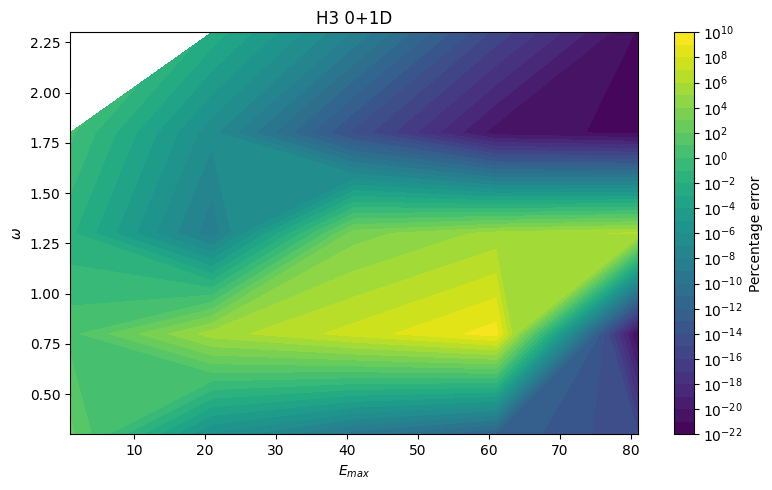


H1 global minimum
H1 minimum percentage error = 4.481099414586761e-22
Occurs at omega = 1.8, Emax = 61.0

H2 at omega ≈ 1.8
Using omega = 1.8
closest available error to H1 minimum:
  Emax = 81.0
  percentage error = 4.948978726260353e-22
  difference from H1 minimum = 4.6787931167359224e-23

H3 at omega ≈ 1.8
Using omega = 1.8
closest available error to H1 minimum:
  Emax = 81.0
  percentage error = 4.948913328682259e-22
  difference from H1 minimum = 4.678139140954985e-23


In [ ]:
import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt

Emax2 = [mp.mpf("1") + i * mp.mpf("20") for i in range(5)]
omega2 = [mp.mpf("0.3") + i * mp.mpf("0.5") for i in range(5)]

N_LEVELS = 100

contour_results_dict = {}
missing_points_dict = {}

for H in ["H1", "H2", "H3"]:
    res = run_emax_omega_scan(
        heff=H,
        omega_list=omega2,
        lam=1.0,
        Emax_list=Emax2,
        Known_E=E0,
        print_table=True,
        hermitianize=False
    )

    Emax_vals = sorted_unique(col(res, 0))
    omega_vals = sorted_unique(col(res, 1))

    # Build index lookups
    emax_to_j = {float(x): j for j, x in enumerate(Emax_vals)}
    omega_to_i = {float(y): i for i, y in enumerate(omega_vals)}

    # Start with a grid full of NaNs
    Z = [[mp.nan for _ in range(len(Emax_vals))] for _ in range(len(omega_vals))]

    # Fill grid from available results
    # Assumes row structure: [Emax, omega, percentage_error, ...]
    for row in res:
        emax, omega, z = row[0], row[1], row[2]
        i = omega_to_i[float(omega)]
        j = emax_to_j[float(emax)]
        Z[i][j] = z

    # Find missing grid points
    missing_points = []
    for i, omega in enumerate(omega_vals):
        for j, emax in enumerate(Emax_vals):
            if mp.isnan(Z[i][j]):
                missing_points.append((emax, omega))

    missing_points_dict[H] = missing_points

    if missing_points:
        print(f"\n{H}: missing {len(missing_points)} grid points")
        print("First few missing points:")
        for emax, omega in missing_points[:10]:
            print(f"  Emax={emax}, omega={omega}")
    else:
        print(f"\n{H}: full grid present")

    # Keep only finite positive values; leave everything else as NaN
    Z_clean = []
    for row in Z:
        new_row = []
        for z in row:
            if (not mp.isnan(z)) and mp.isfinite(z) and z > 0:
                new_row.append(z)
            else:
                new_row.append(mp.nan)
        Z_clean.append(new_row)

    # Find best finite positive value from original cleaned grid
    valid_entries = []
    for i in range(len(omega_vals)):
        for j in range(len(Emax_vals)):
            z = Z_clean[i][j]
            if (not mp.isnan(z)) and mp.isfinite(z) and z > 0:
                valid_entries.append((i, j, z))

    if valid_entries:
        row_idx, col_idx, min_error = min(valid_entries, key=lambda t: t[2])
        best_omega = omega_vals[row_idx]
        best_Emax = Emax_vals[col_idx]
        Z_valid = [t[2] for t in valid_entries]
        median_log_error = 10 ** (sum(mp.log10(z) for z in Z_valid) / len(Z_valid))
        mean_z = sum(Z_valid) / len(Z_valid)
        std_error = mp.sqrt(sum((z - mean_z) ** 2 for z in Z_valid) / len(Z_valid))

        min_log10 = min(mp.log10(z) for z in Z_valid)
        max_log10 = max(mp.log10(z) for z in Z_valid)
    else:
        min_error = mp.nan
        best_omega = mp.nan
        best_Emax = mp.nan
        median_log_error = mp.nan
        std_error = mp.nan
        min_log10 = mp.nan
        max_log10 = mp.nan

    print(f"{H}:")
    print(f"Minimum Percentage error = {min_error}")
    print(f"Occurs at Emax = {best_Emax}, Omega = {best_omega}")
    print(f"Median Percentage error  = {median_log_error} with std = {std_error}")
    print(f"log10(error) range = [{min_log10}, {max_log10}]")

    # Convert axes to floats
    Xf = np.array([float(x) for x in Emax_vals], dtype=float)
    Yf = np.array([float(y) for y in omega_vals], dtype=float)

    # Build log10(error) grid directly, leaving invalid points as NaN
    Zlog = []
    for row in Z_clean:
        new_row = []
        for z in row:
            if (not mp.isnan(z)) and mp.isfinite(z) and z > 0:
                new_row.append(float(mp.log10(z)))
            else:
                new_row.append(np.nan)
        Zlog.append(new_row)

    Zlog = np.array(Zlog, dtype=float)
    Zmasked = np.ma.masked_invalid(Zlog)

    contour_results_dict[H] = (Xf, Yf, Zlog)

    fig, ax = plt.subplots(figsize=(8, 5))

    finite_logs = Zlog[np.isfinite(Zlog)]
    if finite_logs.size == 0:
        raise ValueError(f"No finite log10(error) values available to plot for {H}")

    # Use integer decades as the actual contour boundaries
    level_min = int(np.floor(finite_logs.min()))
    level_max = int(np.ceil(finite_logs.max()))
    levels = np.arange(level_min, level_max + 1, 1)

    cf = ax.contourf(
        Xf,
        Yf,
        Zmasked,
        levels=levels,
        vmin=level_min,
        vmax=level_max
    )

    cbar = fig.colorbar(cf, ax=ax, boundaries=levels)
    cbar.set_label("Percentage error")

    # Put ticks only where levels actually exist
    tick_locs = np.arange(level_min, level_max + 1, 2)
    cbar.set_ticks(tick_locs)
    cbar.set_ticklabels([rf"$10^{{{n}}}$" for n in tick_locs])

    ax.set_title(f"{H} 0+1D")
    ax.set_xlabel(r"$E_{max}$")
    ax.set_ylabel(r"$\omega$")

    plt.tight_layout()
    plt.show()

def nearest_index(arr, value):
    arr = np.asarray(arr, dtype=float)
    return int(np.argmin(np.abs(arr - float(value))))

# H1 global minimum
Xf_H1, Yf_H1, Zlog_H1 = contour_results_dict["H1"]
finite_idx_H1 = np.argwhere(np.isfinite(Zlog_H1))

if finite_idx_H1.size == 0:
    raise ValueError("No finite H1 values found.")

i_H1_min, j_H1_min = min(
    finite_idx_H1,
    key=lambda idx: Zlog_H1[idx[0], idx[1]]
)

H1_min_log10 = Zlog_H1[i_H1_min, j_H1_min]
H1_min_error = 10 ** H1_min_log10
H1_best_omega = Yf_H1[i_H1_min]
H1_best_Emax = Xf_H1[j_H1_min]

print("\n" + "=" * 60)
print("H1 global minimum")
print(f"H1 minimum percentage error = {H1_min_error}")
print(f"Occurs at omega = {H1_best_omega}, Emax = {H1_best_Emax}")

# H2 and H3 at same omega as H1 optimum
for H in ["H2", "H3"]:
    Xf, Yf, Zlog = contour_results_dict[H]

    i_same_omega = nearest_index(Yf, H1_best_omega)
    omega_used = Yf[i_same_omega]
    row_logs = Zlog[i_same_omega, :]

    finite_js = [j for j in range(len(Xf)) if np.isfinite(row_logs[j])]
    if not finite_js:
        print(f"\n{H}: no finite values found at omega ≈ {H1_best_omega}")
        continue

    # First try to find the smallest Emax that achieves error <= H1 minimum
    eligible_js = [j for j in finite_js if (10 ** row_logs[j]) <= H1_min_error]

    if eligible_js:
        j_match = min(eligible_js, key=lambda j: Xf[j])
        match_type = "smallest Emax achieving error <= H1 minimum"
    else:
        # Fallback: choose the closest error if exact/better match does not exist
        row_errors = np.array([10 ** row_logs[j] for j in finite_js], dtype=float)
        best_local_idx = int(np.argmin(np.abs(row_errors - H1_min_error)))
        j_match = finite_js[best_local_idx]
        match_type = "closest available error to H1 minimum"

    matched_Emax = Xf[j_match]
    matched_error = 10 ** row_logs[j_match]

    print(f"\n{H} at omega ≈ {H1_best_omega}")
    print(f"Using omega = {omega_used}")
    print(f"{match_type}:")
    print(f"  Emax = {matched_Emax}")
    print(f"  percentage error = {matched_error}")
    print(f"  difference from H1 minimum = {abs(matched_error - H1_min_error)}")

print("=" * 60)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, wspace=0.0, hspace=0.0)

ax_H1 = fig.add_subplot(gs[0, 0])
ax_H2 = fig.add_subplot(gs[0, 1])
ax_H3 = fig.add_subplot(gs[1, 0])

axes = {
    "H1": ax_H1,
    "H2": ax_H2,
    "H3": ax_H3,
}


all_finite_logs = []
for H in ["H1", "H2", "H3"]:
    Xf, Yf, Zlog = contour_results_dict[H]
    finite_vals = Zlog[np.isfinite(Zlog)]
    all_finite_logs.extend(finite_vals)

if len(all_finite_logs) == 0:
    raise ValueError("No finite log10(error) values found in contour_results_dict.")

all_finite_logs = np.array(all_finite_logs, dtype=float)

level_min = int(np.floor(all_finite_logs.min()))
level_max = int(np.ceil(all_finite_logs.max()))

# integer-decade contour boundaries
levels = np.arange(level_min, level_max + 1, 1)

cf = None

for H, ax in axes.items():
    Xf, Yf, Zlog = contour_results_dict[H]

    # Mask invalid points so missing grid points are left blank
    Zmasked = np.ma.masked_invalid(Zlog)

    cf = ax.contourf(
        Xf,
        Yf,
        Zmasked,
        levels=levels,
        vmin=level_min,
        vmax=level_max
    )

    ax.text(
        0, 0.98,
        f"{H}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
        color="black"
    )

    if ax is ax_H1:
        ax.tick_params(labelbottom=False)

    if ax is ax_H2:
        ax.set_xlabel(r"$E_{max}$", fontsize=fontsize)
        ax.tick_params(labelbottom=True)
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

ax_H1.set_ylabel(r"$\omega$", fontsize=fontsize)
ax_H3.set_ylabel(r"$\omega$", fontsize=fontsize)
ax_H3.set_xlabel(r"$E_{max}$", fontsize=fontsize)


cbar = fig.colorbar(cf, ax=[ax_H1, ax_H2, ax_H3], shrink=0.9, boundaries=levels)
cbar.set_label("Relative error (%)", fontsize=fontsize)

tick_locs = np.arange(level_min, level_max + 1, 2)
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([rf"$10^{{{n}}}$" for n in tick_locs])


fig.suptitle(r"Ground State, $\lambda_0 = 1$", y= 0.91, x=0.45)

fig.savefig(
    "HTET.png",  # PDF is best for papers
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Scanning omega = 0.3
Scanning omega = 0.35
Scanning omega = 0.4
Scanning omega = 0.45
Scanning omega = 0.5
Scanning omega = 0.55
Scanning omega = 0.6
Scanning omega = 0.65
Scanning omega = 0.7
Scanning omega = 0.75
Scanning omega = 0.8
Scanning omega = 0.85
Scanning omega = 0.9
Scanning omega = 0.95
Scanning omega = 1.0
Scanning omega = 1.05
Scanning omega = 1.1
Scanning omega = 1.15
Scanning omega = 1.2
Scanning omega = 1.25
Scanning omega = 1.3
Scanning omega = 1.35
Scanning omega = 1.4
Scanning omega = 1.45
Scanning omega = 1.5
Scanning omega = 1.55
Scanning omega = 1.6
Scanning omega = 1.65
Scanning omega = 1.7
Scanning omega = 1.75
Scanning omega = 1.8
Scanning omega = 1.85
Scanning omega = 1.9
Scanning omega = 1.95
Scanning omega = 2.0
Scanning omega = 2.05
  failed at omega=2.05, Emax=1.0: P-space is empty.
Scanning omega = 2.1
  failed at omega=2.1, Emax=1.0: P-space is empty.
Scanning omega = 2.15
  failed at omega=2.15, Emax=1.0: P-space is empty.
Scanning omega = 2.2
  faile

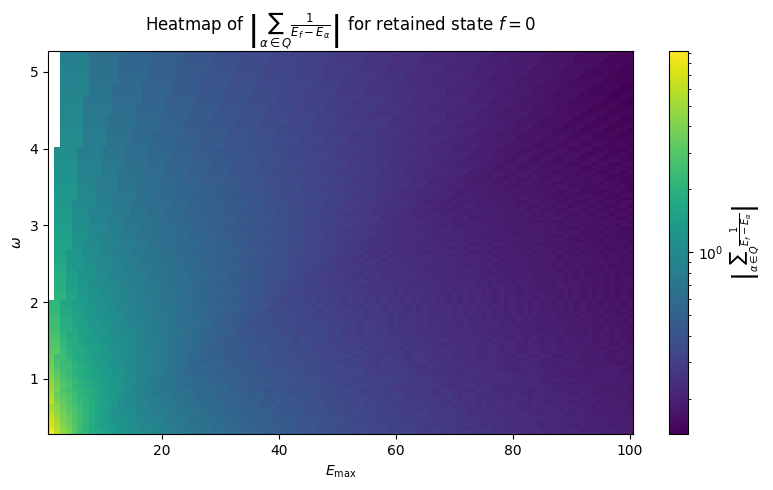

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import mpmath as mp


omega_list = [mp.mpf("0.3") + i * mp.mpf("0.05") for i in range(100)]   # omega scan
Emax_list = [mp.mpf("1") + i * mp.mpf("1") for i in range(100)]          # Emax scan
f_state_index = 0   # 0 = lowest retained state, 1 = next retained state, etc.


def choose_N_uv(Emax, omega, extra=20):
    Emax = float(Emax)
    omega = float(omega)
    return max(int(np.floor(Emax / max(omega, 1e-12))) + extra, 40)


def denominator_sum_H2_part(omega, Emax, f_state_index=0, N_uv=None):
    """
    Returns the pure denominator piece

        sum_{alpha in Q} 1 / (E_f - E_alpha)

    for one chosen retained state f.
    """
    omega = mp.mpf(omega)
    Emax = mp.mpf(Emax)

    if N_uv is None:
        N_uv = choose_N_uv(Emax, omega, extra=20)

    P, Q, En = indices_below_Emax(omega, Emax, N_uv)

    if len(P) == 0:
        raise ValueError("P-space is empty.")
    if len(Q) == 0:
        raise ValueError("Q-space is empty; increase N_uv.")

    P_sorted = sorted(P, key=lambda i: En[i])
    Q_sorted = sorted(Q, key=lambda i: En[i])

    if f_state_index < 0 or f_state_index >= len(P_sorted):
        raise IndexError(
            f"f_state_index={f_state_index} out of range; len(P)={len(P_sorted)}"
        )

    f = P_sorted[f_state_index]
    Ef = En[f]

    D2_den = mp.mpc("0")
    for alpha in Q_sorted:
        D2_den += 1 / (Ef - En[alpha])

    return {
        "omega": omega,
        "Emax": Emax,
        "f_state_index": f_state_index,
        "f_basis_index": f,
        "Ef": Ef,
        "denominator_sum": D2_den,
        "denominator_sum_abs": abs(D2_den),
        "P_dim": len(P_sorted),
        "Q_dim": len(Q_sorted),
    }


def scan_denominator_sum_heatmap(omega_list, Emax_list, f_state_index=0):
    """
    Build a 2D array over (omega, Emax) of

        sum_{alpha in Q} 1 / (E_f - E_alpha)

    for one chosen retained state f.
    """
    shape = (len(omega_list), len(Emax_list))

    den_sum_real = np.full(shape, np.nan)
    den_sum_imag = np.full(shape, np.nan)
    den_sum_abs = np.full(shape, np.nan)
    Ef_grid = np.full(shape, np.nan)
    P_dim = np.full(shape, np.nan)
    Q_dim = np.full(shape, np.nan)

    for i, omega in enumerate(omega_list):
        print(f"Scanning omega = {omega}")
        for j, Emax in enumerate(Emax_list):
            try:
                vals = denominator_sum_H2_part(
                    omega=omega,
                    Emax=Emax,
                    f_state_index=f_state_index
                )

                D = vals["denominator_sum"]

                den_sum_real[i, j] = float(mp.re(D))
                den_sum_imag[i, j] = float(mp.im(D))
                den_sum_abs[i, j] = float(abs(D))
                Ef_grid[i, j] = float(vals["Ef"])
                P_dim[i, j] = vals["P_dim"]
                Q_dim[i, j] = vals["Q_dim"]

            except Exception as e:
                print(f"  failed at omega={omega}, Emax={Emax}: {e}")

    return {
        "omega_list": [float(w) for w in omega_list],
        "Emax_list": [float(e) for e in Emax_list],
        "den_sum_real": den_sum_real,
        "den_sum_imag": den_sum_imag,
        "den_sum_abs": den_sum_abs,
        "Ef_grid": Ef_grid,
        "P_dim": P_dim,
        "Q_dim": Q_dim,
        "f_state_index": f_state_index,
    }

def plot_denominator_sum_heatmap(scan, plot_abs=True):
    """
    Plot a heatmap of either
      - |sum_alpha 1/(E_f - E_alpha)|   if plot_abs=True
      - Re[sum_alpha 1/(E_f - E_alpha)] if plot_abs=False
    """
    X = np.array(scan["Emax_list"])
    Y = np.array(scan["omega_list"])

    if plot_abs:
        Z = scan["den_sum_abs"]

        positive = Z[np.isfinite(Z) & (Z > 0)]
        if positive.size == 0:
            raise ValueError("No positive values available for log-scaled heatmap.")

        norm = colors.LogNorm(vmin=np.min(positive), vmax=np.max(positive))
        cmap = "viridis"

        plt.figure(figsize=(8, 5))
        mesh = plt.pcolormesh(X, Y, Z, shading="auto", norm=norm, cmap=cmap)
        cbar = plt.colorbar(mesh)
        cbar.set_label(r"$\left|\sum_{\alpha\in Q}\frac{1}{E_f-E_\alpha}\right|$")

        plt.xlabel(r"$E_{\max}$")
        plt.ylabel(r"$\omega$")
        plt.title(
            rf"Heatmap of $\left|\sum_{{\alpha\in Q}}\frac{{1}}{{E_f-E_\alpha}}\right|$ "
            rf"for retained state $f={scan['f_state_index']}$"
        )
        plt.tight_layout()
        plt.show()

    else:
        Z = scan["den_sum_real"]

        vmax = np.nanmax(np.abs(Z))
        vmin = -vmax

        plt.figure(figsize=(8, 5))
        mesh = plt.pcolormesh(X, Y, Z, shading="auto", cmap="coolwarm", vmin=vmin, vmax=vmax)
        cbar = plt.colorbar(mesh)
        cbar.set_label(r"$\sum_{\alpha\in Q}\frac{1}{E_f-E_\alpha}$")

        plt.xlabel(r"$E_{\max}$")
        plt.ylabel(r"$\omega$")
        plt.title(
            rf"Heatmap of $\sum_{{\alpha\in Q}}\frac{{1}}{{E_f-E_\alpha}}$ "
            rf"for retained state $f={scan['f_state_index']}$"
        )
        plt.tight_layout()
        plt.show()

scan = scan_denominator_sum_heatmap(
    omega_list=omega_list,
    Emax_list=Emax_list,
    f_state_index=0
)

plot_denominator_sum_heatmap(
    scan,
    plot_abs=True   # True for magnitude, False for signed real part
)

In [ ]:
def plot_denominator_sum_heatmap(scan, plot_abs=True):
    """
    Plot a heatmap of either
      - |sum_alpha 1/(E_f - E_alpha)|   if plot_abs=True
      - Re[sum_alpha 1/(E_f - E_alpha)] if plot_abs=False
    """
    X = np.array(scan["Emax_list"])
    Y = np.array(scan["omega_list"])

    if plot_abs:
        Z = scan["den_sum_abs"]

        positive = Z[np.isfinite(Z) & (Z > 0)]
        if positive.size == 0:
            raise ValueError("No positive values available for log-scaled heatmap.")

        norm = colors.LogNorm(vmin=np.min(positive), vmax=np.max(positive))
        cmap = "viridis"

        plt.figure(figsize=(8, 5))
        mesh = plt.pcolormesh(X, Y, Z, shading="auto", norm=norm, cmap=cmap)
        cbar = plt.colorbar(mesh)
        cbar.set_label(r"$\left|\sum_{\alpha\in Q}\frac{1}{E_f-E_\alpha}\right|$")

        plt.xlabel(r"$E_{\max}$")
        plt.ylabel(r"$\omega$")
        plt.title(
            rf"Heatmap of $\left|\sum_{{\alpha\in Q}}\frac{{1}}{{E_f-E_\alpha}}\right|$ "
            rf"for retained state $f={scan['f_state_index']}$"
        )
        plt.tight_layout()
        plt.show()

    else:
        Z = scan["den_sum_real"]

        vmax = np.nanmax(np.abs(Z))
        vmin = -vmax

        plt.figure(figsize=(8, 5))
        mesh = plt.pcolormesh(X, Y, Z, shading="auto", cmap="coolwarm", vmin=vmin, vmax=vmax)
        cbar = plt.colorbar(mesh)
        cbar.set_label(r"$\sum_{\alpha\in Q}\frac{1}{E_f-E_\alpha}$")

        plt.xlabel(r"$E_{\max}$")
        plt.ylabel(r"$\omega$")
        plt.title(
            rf"Heatmap of $\sum_{{\alpha\in Q}}\frac{{1}}{{E_f-E_\alpha}}$ "
            rf"for retained state $f={scan['f_state_index']}$"
        )
        plt.tight_layout()
        plt.show()

plot_denominator_sum_heatmap(
    scan,
    plot_abs=True   # True for magnitude, False for signed real part
)

KeyError: 'den_sum_abs'

Scanning Emax = 1.0
  failed at Emax=1.0, omega=2.05: P-space is empty.
  failed at Emax=1.0, omega=2.1: P-space is empty.
  failed at Emax=1.0, omega=2.15: P-space is empty.
  failed at Emax=1.0, omega=2.2: P-space is empty.
  failed at Emax=1.0, omega=2.25: P-space is empty.
  failed at Emax=1.0, omega=2.3: P-space is empty.
  failed at Emax=1.0, omega=2.35: P-space is empty.
  failed at Emax=1.0, omega=2.4: P-space is empty.
  failed at Emax=1.0, omega=2.45: P-space is empty.
Scanning Emax = 2.0
Scanning Emax = 3.0
Scanning Emax = 4.0
Scanning Emax = 5.0
Scanning Emax = 6.0
Scanning Emax = 7.0
Scanning Emax = 8.0
Scanning Emax = 9.0
Scanning Emax = 10.0
Scanning Emax = 11.0
Scanning Emax = 12.0
Scanning Emax = 13.0
Scanning Emax = 14.0
Scanning Emax = 15.0
Scanning Emax = 16.0
Scanning Emax = 17.0
Scanning Emax = 18.0
Scanning Emax = 19.0
Scanning Emax = 20.0
Scanning Emax = 21.0
Scanning Emax = 22.0
Scanning Emax = 23.0
Scanning Emax = 24.0
Scanning Emax = 25.0
Scanning Emax = 26.0

C:\Users\alexm\AppData\Local\Temp\ipykernel_16140\3289143098.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


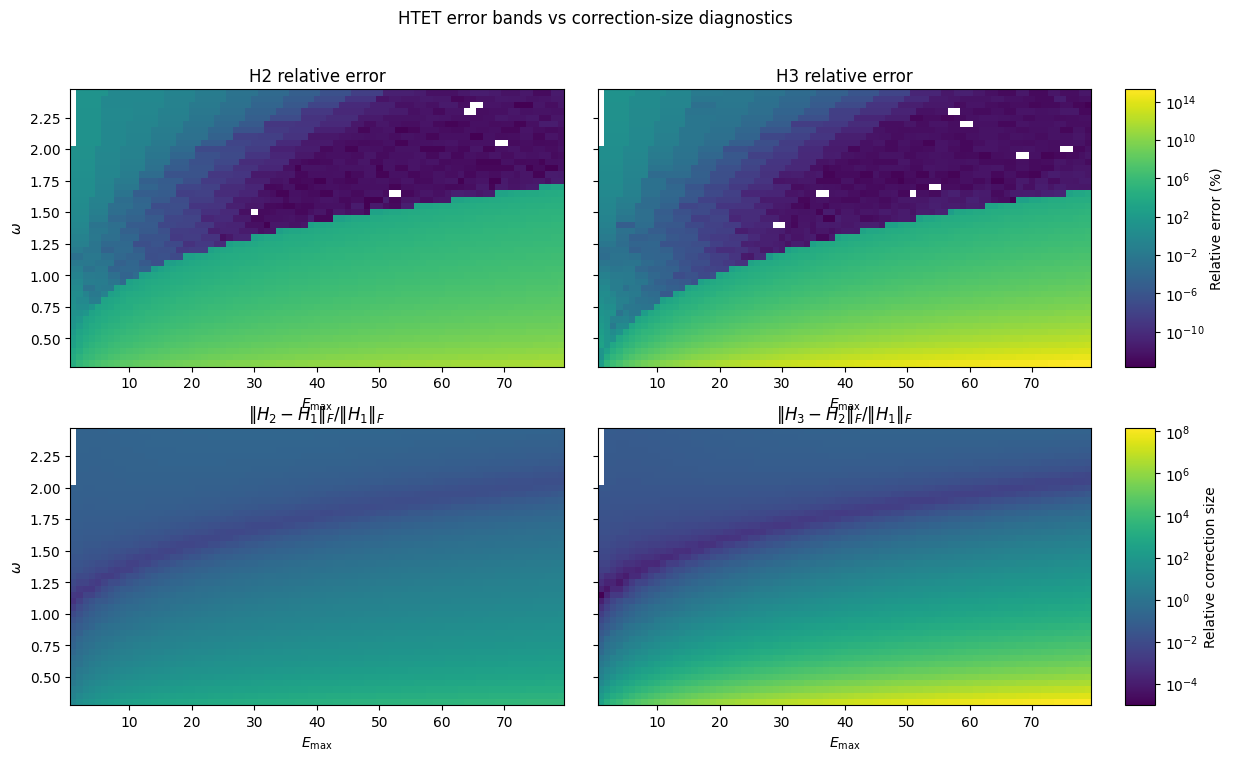

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
import mpmath as mp


lam_scan = mp.mpf("1.0")

omega_list = [mp.mpf("0.3") + i * mp.mpf("0.05") for i in range(44)]   # 0.3 -> 2.7
Emax_list  = [mp.mpf("1") + i * mp.mpf("1") for i in range(79)]      # 8 -> 96

try:
    Known_E = mp.mpf(E0)
except NameError:
    Known_E = mp.mpf("0.5277361273")


def choose_N_uv(Emax, omega, extra=20):
    Emax = float(Emax)
    omega = float(omega)
    return max(int(np.floor(Emax / max(omega, 1e-12))) + extra, 40)

def matrix_to_numpy(M):
    if isinstance(M, np.ndarray):
        return M.astype(np.complex128)
    try:
        return np.array([[complex(M[i, j]) for j in range(M.cols)] for i in range(M.rows)],
                        dtype=np.complex128)
    except Exception:
        return np.array(M, dtype=np.complex128)

def frob_norm(M):
    return np.linalg.norm(M, ord='fro')

def safe_rel_norm(delta, base, eps=1e-30):
    return frob_norm(delta) / max(frob_norm(base), eps)

def ground_state_energy_from_any_matrix(H):
    H_np = matrix_to_numpy(H)
    evals = np.linalg.eigvals(H_np)
    idx = np.argmin(np.real(evals))
    return evals[idx]


def build_heff_direct(N_uv, omega, lam, Emax):

    omega = mp.mpf(omega)
    lam   = mp.mpf(lam)
    Emax  = mp.mpf(Emax)

    H0 = build_H0(N_uv, omega)
    V  = build_V(N_uv, omega, lam)

    P, Q, En = indices_below_Emax(omega, Emax, N_uv)

    if len(P) == 0:
        raise ValueError("P-space is empty.")
    if len(Q) == 0:
        raise ValueError("Q-space is empty.")

    H0_PP = submatrix(H0, P, P)
    V_PP  = submatrix(V, P, P)
    V_PQ  = submatrix(V, P, Q)
    V_QP  = submatrix(V, Q, P)
    V_QQ  = submatrix(V, Q, Q)

    EP = [En[i] for i in P]
    EQ = [En[i] for i in Q]

    nP = len(P)
    nQ = len(Q)


    H1 = H0_PP + V_PP

    dH2 = mp.matrix(nP, nP)
    for f in range(nP):
        Ef = EP[f]
        for i in range(nP):
            s = mp.mpc("0")
            for a in range(nQ):
                s += V_PQ[f, a] * V_QP[a, i] / (Ef - EQ[a])
            dH2[f, i] = s

    H2 = H1 + dH2

    dH3 = mp.matrix(nP, nP)

    # Precompute A_{ab} = V_{ab}/(E_a - E_b) for a in P, b in Q
    A = mp.matrix(nP, nQ)
    for a in range(nP):
        for b in range(nQ):
            A[a, b] = V_PQ[a, b] / (EP[a] - EQ[b])

    for f in range(nP):
        Ef = EP[f]
        inv_f = [1 / (Ef - EQ[b]) for b in range(nQ)]

        # First H3 term:
        # sum_{a,b in Q} V_fa V_ab V_bi / [(Ef-Ea)(Ef-Eb)]
        term1 = [mp.mpc("0") for _ in range(nP)]
        for i in range(nP):
            s = mp.mpc("0")
            for a in range(nQ):
                for b in range(nQ):
                    s += V_PQ[f, a] * V_QQ[a, b] * V_QP[b, i] / ((Ef - EQ[a]) * (Ef - EQ[b]))
            term1[i] = s

        # Second H3 term:
        # sum_{a in P, b in Q} V_fa V_ab V_bi / [(Ea-Eb)(Ef-Eb)]
        for i in range(nP):
            s = mp.mpc("0")
            for a in range(nP):
                for b in range(nQ):
                    s += V_PP[f, a] * V_PQ[a, b] * V_QP[b, i] / ((EP[a] - EQ[b]) * (Ef - EQ[b]))
            dH3[f, i] = term1[i] - s

    H3 = H2 + dH3

    return H1, H2, H3, P, Q


def scan_htet_correction_norms_direct(omega_list, Emax_list, lam, Known_E):
    shape = (len(omega_list), len(Emax_list))

    H1_err = np.full(shape, np.nan)
    H2_err = np.full(shape, np.nan)
    H3_err = np.full(shape, np.nan)

    rel_H2 = np.full(shape, np.nan)
    rel_H3 = np.full(shape, np.nan)

    Pdim = np.full(shape, np.nan)
    Qdim = np.full(shape, np.nan)

    for j, Emax in enumerate(Emax_list):
        print(f"Scanning Emax = {Emax}")
        for i, omega in enumerate(omega_list):
            try:
                N_uv = choose_N_uv(Emax, omega, extra=20)

                H1_mat, H2_mat, H3_mat, P, Q = build_heff_direct(
                    N_uv=N_uv,
                    omega=omega,
                    lam=lam,
                    Emax=Emax
                )

                H1 = matrix_to_numpy(H1_mat)
                H2 = matrix_to_numpy(H2_mat)
                H3 = matrix_to_numpy(H3_mat)

                dH2 = H2 - H1
                dH3 = H3 - H2

                rel_H2[i, j] = safe_rel_norm(dH2, H1)
                rel_H3[i, j] = safe_rel_norm(dH3, H1)

                Pdim[i, j] = len(P)
                Qdim[i, j] = len(Q)

                E1 = ground_state_energy_from_any_matrix(H1)
                E2 = ground_state_energy_from_any_matrix(H2)
                E3 = ground_state_energy_from_any_matrix(H3)

                H1_err[i, j] = 100.0 * abs((complex(E1) - complex(Known_E)) / complex(Known_E))
                H2_err[i, j] = 100.0 * abs((complex(E2) - complex(Known_E)) / complex(Known_E))
                H3_err[i, j] = 100.0 * abs((complex(E3) - complex(Known_E)) / complex(Known_E))

            except Exception as e:
                print(f"  failed at Emax={Emax}, omega={omega}: {e}")

    return {
        "omega_list": np.array([float(x) for x in omega_list]),
        "Emax_list": np.array([float(x) for x in Emax_list]),
        "H1_err": H1_err,
        "H2_err": H2_err,
        "H3_err": H3_err,
        "rel_H2": rel_H2,
        "rel_H3": rel_H3,
        "Pdim": Pdim,
        "Qdim": Qdim,
    }


def _positive_log_norm(*arrays, floor=1e-24):
    vals = np.concatenate([a.ravel() for a in arrays])
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size == 0:
        return colors.LogNorm(vmin=floor, vmax=1.0)
    return colors.LogNorm(vmin=max(vals.min(), floor), vmax=vals.max())

def plot_htet_breakdown_diagnostics(scan):
    X = scan["Emax_list"]
    Y = scan["omega_list"]

    err_norm = _positive_log_norm(scan["H2_err"], scan["H3_err"], floor=1e-24)
    rel_norm = _positive_log_norm(scan["rel_H2"], scan["rel_H3"], floor=1e-8)

    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.06], hspace=0.22, wspace=0.10)

    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.pcolormesh(X, Y, scan["H2_err"], shading="auto", norm=err_norm)
    ax1.set_title("H2 relative error")
    ax1.set_ylabel(r"$\omega$")
    ax1.set_xlabel(r"$E_{\max}$")

    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.pcolormesh(X, Y, scan["H3_err"], shading="auto", norm=err_norm)
    ax2.set_title("H3 relative error")
    ax2.set_xlabel(r"$E_{\max}$")
    ax2.set_yticklabels([])

    cax1 = fig.add_subplot(gs[0, 2])
    cb1 = fig.colorbar(im2, cax=cax1)
    cb1.set_label("Relative error (%)")

    ax3 = fig.add_subplot(gs[1, 0])
    im3 = ax3.pcolormesh(X, Y, scan["rel_H2"], shading="auto", norm=rel_norm)
    ax3.set_title(r"$\|H_2-H_1\|_F / \|H_1\|_F$")
    ax3.set_ylabel(r"$\omega$")
    ax3.set_xlabel(r"$E_{\max}$")

    ax4 = fig.add_subplot(gs[1, 1])
    im4 = ax4.pcolormesh(X, Y, scan["rel_H3"], shading="auto", norm=rel_norm)
    ax4.set_title(r"$\|H_3-H_2\|_F / \|H_1\|_F$")
    ax4.set_xlabel(r"$E_{\max}$")
    ax4.set_yticklabels([])

    cax2 = fig.add_subplot(gs[1, 2])
    cb2 = fig.colorbar(im4, cax=cax2)
    cb2.set_label("Relative correction size")

    plt.suptitle("HTET error bands vs correction-size diagnostics", y=0.98)
    plt.tight_layout()
    plt.show()

scan = scan_htet_correction_norms_direct(
    omega_list=omega_list,
    Emax_list=Emax_list,
    lam=lam_scan,
    Known_E=Known_E
)



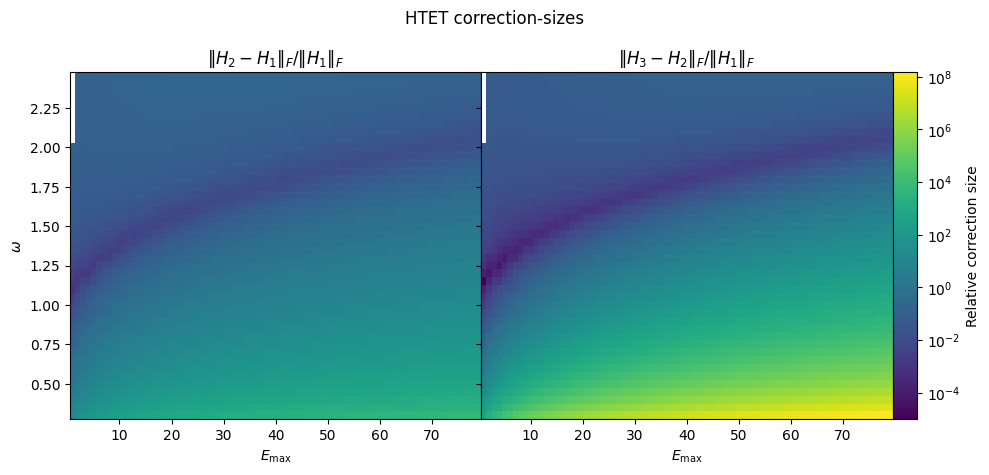

In [ ]:
def plot_htet_breakdown_diagnostics(scan):
    X = scan["Emax_list"]
    Y = scan["omega_list"]

    rel_norm = _positive_log_norm(scan["rel_H2"], scan["rel_H3"])

    fig = plt.figure(figsize=(10, 4.8))
    gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.06], wspace=0)

    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.pcolormesh(X, Y, scan["rel_H2"], shading="auto", norm=rel_norm)
    ax1.set_title(r"$\|H_2-H_1\|_F / \|H_1\|_F$")
    ax1.set_ylabel(r"$\omega$")
    ax1.set_xlabel(r"$E_{\max}$")

    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.pcolormesh(X, Y, scan["rel_H3"], shading="auto", norm=rel_norm)
    ax2.set_title(r"$\|H_3-H_2\|_F / \|H_1\|_F$")
    ax2.set_xlabel(r"$E_{\max}$")
    ax2.set_yticklabels([])

    cax = fig.add_subplot(gs[0, 2])
    cb = fig.colorbar(im2, cax=cax)
    cb.set_label("Relative correction size")

    plt.suptitle("HTET correction-sizes", y=0.98)
    plt.tight_layout()
    plt.show()

plot_htet_breakdown_diagnostics(scan)

Scanning edge-coupling diagnostics: Emax = 1.0
  failed at Emax=1.0, omega=2.05: P-space is empty.
  failed at Emax=1.0, omega=2.1: P-space is empty.
  failed at Emax=1.0, omega=2.15: P-space is empty.
  failed at Emax=1.0, omega=2.2: P-space is empty.
  failed at Emax=1.0, omega=2.25: P-space is empty.
  failed at Emax=1.0, omega=2.3: P-space is empty.
  failed at Emax=1.0, omega=2.35: P-space is empty.
  failed at Emax=1.0, omega=2.4: P-space is empty.
  failed at Emax=1.0, omega=2.45: P-space is empty.
Scanning edge-coupling diagnostics: Emax = 2.0
Scanning edge-coupling diagnostics: Emax = 3.0
Scanning edge-coupling diagnostics: Emax = 4.0
Scanning edge-coupling diagnostics: Emax = 5.0
Scanning edge-coupling diagnostics: Emax = 6.0
Scanning edge-coupling diagnostics: Emax = 7.0
Scanning edge-coupling diagnostics: Emax = 8.0
Scanning edge-coupling diagnostics: Emax = 9.0
Scanning edge-coupling diagnostics: Emax = 10.0
Scanning edge-coupling diagnostics: Emax = 11.0
Scanning edge-cou

C:\Users\alexm\AppData\Local\Temp\ipykernel_16140\2040957268.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


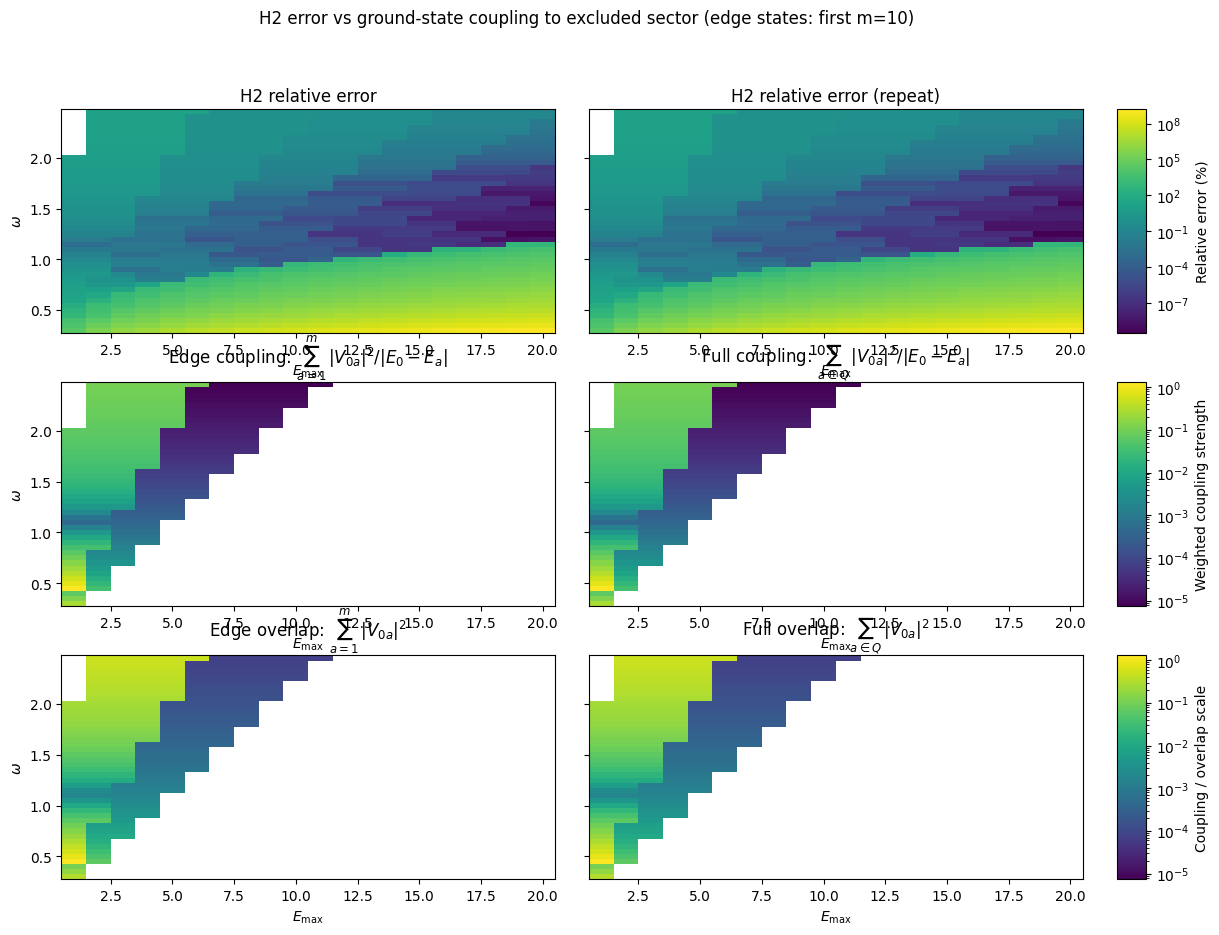

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
import mpmath as mp

def choose_N_uv(Emax, omega, extra=20):
    Emax = float(Emax)
    omega = float(omega)
    return max(int(np.floor(Emax / max(omega, 1e-12))) + extra, 40)


def edge_coupling_H2(V_PQ, EP, EQ, m=10, weighted=True):

    if len(EQ) == 0:
        return np.nan

    Ef = EP[0]
    m = min(m, len(EQ))
    s = 0.0

    for a in range(m):
        num = abs(complex(V_PQ[0, a]))**2
        if weighted:
            den = abs(float(Ef - EQ[a]))
            s += num / max(den, 1e-30)
        else:
            s += num

    return float(s)



    if len(EQ) == 0:
        return np.nan

    Ef = EP[0]
    s = 0.0

    for a in range(len(EQ)):
        num = abs(complex(V_PQ[0, a]))**2
        if weighted:
            den = abs(float(Ef - EQ[a]))
            s += num / max(den, 1e-30)
        else:
            s += num

    return float(s)


def scan_htet_edge_coupling_diagnostics(omega_list, Emax_list, lam, Known_E, m_edge=10):
    """
    Uses the same scan grid as your existing code, but adds diagnostics
    aimed at explaining the H2 error band:
      - edge_H2_weighted: sum over first m excluded states of |V_0a|^2 / |E0-Ea|
      - edge_H2_unweighted: sum over first m excluded states of |V_0a|^2
      - full_H2_weighted: same sum over all excluded states
      - full_H2_unweighted: same sum over all excluded states
    """
    shape = (len(omega_list), len(Emax_list))

    H1_err = np.full(shape, np.nan)
    H2_err = np.full(shape, np.nan)
    H3_err = np.full(shape, np.nan)

    rel_H2 = np.full(shape, np.nan)
    rel_H3 = np.full(shape, np.nan)

    edge_H2_weighted   = np.full(shape, np.nan)
    edge_H2_unweighted = np.full(shape, np.nan)
    full_H2_weighted   = np.full(shape, np.nan)
    full_H2_unweighted = np.full(shape, np.nan)

    Pdim = np.full(shape, np.nan)
    Qdim = np.full(shape, np.nan)

    for j, Emax in enumerate(Emax_list):
        print(f"Scanning edge-coupling diagnostics: Emax = {Emax}")
        for i, omega in enumerate(omega_list):
            try:
                N_uv = choose_N_uv(Emax, omega, extra=20)

                omega_mp = mp.mpf(omega)
                lam_mp   = mp.mpf(lam)
                Emax_mp  = mp.mpf(Emax)

                # Build ingredients directly so V_PQ is accessible
                H0 = build_H0(N_uv, omega_mp)
                V  = build_V(N_uv, omega_mp, lam_mp)

                P, Q, En = indices_below_Emax(omega_mp, Emax_mp, N_uv)

                if len(P) == 0:
                    raise ValueError("P-space is empty.")
                if len(Q) == 0:
                    raise ValueError("Q-space is empty.")

                H0_PP = submatrix(H0, P, P)
                V_PP  = submatrix(V, P, P)
                V_PQ  = submatrix(V, P, Q)
                V_QP  = submatrix(V, Q, P)
                V_QQ  = submatrix(V, Q, Q)

                EP = [En[k] for k in P]
                EQ = [En[k] for k in Q]

                nP = len(P)
                nQ = len(Q)

                # ---------------- H1 ----------------
                H1_mat = H0_PP + V_PP

                # ---------------- dH2 ----------------
                dH2_mat = mp.matrix(nP, nP)
                for f in range(nP):
                    Ef = EP[f]
                    for k in range(nP):
                        s = mp.mpc("0")
                        for a in range(nQ):
                            s += V_PQ[f, a] * V_QP[a, k] / (Ef - EQ[a])
                        dH2_mat[f, k] = s

                H2_mat = H1_mat + dH2_mat

                # ---------------- dH3 ----------------
                dH3_mat = mp.matrix(nP, nP)
                for f in range(nP):
                    Ef = EP[f]
                    for k in range(nP):
                        # term 1
                        t1 = mp.mpc("0")
                        for a in range(nQ):
                            for b in range(nQ):
                                t1 += V_PQ[f, a] * V_QQ[a, b] * V_QP[b, k] / ((Ef - EQ[a]) * (Ef - EQ[b]))

                        # term 2
                        t2 = mp.mpc("0")
                        for a in range(nP):
                            for b in range(nQ):
                                t2 += V_PP[f, a] * V_PQ[a, b] * V_QP[b, k] / ((EP[a] - EQ[b]) * (Ef - EQ[b]))

                        dH3_mat[f, k] = t1 - t2

                H3_mat = H2_mat + dH3_mat

                # Convert for numerical diagnostics
                H1 = matrix_to_numpy(H1_mat)
                H2 = matrix_to_numpy(H2_mat)
                H3 = matrix_to_numpy(H3_mat)

                dH2 = H2 - H1
                dH3 = H3 - H2

                # Existing diagnostics
                rel_H2[i, j] = safe_rel_norm(dH2, H1)
                rel_H3[i, j] = safe_rel_norm(dH3, H1)

                Pdim[i, j] = len(P)
                Qdim[i, j] = len(Q)

                E1 = ground_state_energy_from_any_matrix(H1)
                E2 = ground_state_energy_from_any_matrix(H2)
                E3 = ground_state_energy_from_any_matrix(H3)

                H1_err[i, j] = 100.0 * abs((complex(E1) - complex(Known_E)) / complex(Known_E))
                H2_err[i, j] = 100.0 * abs((complex(E2) - complex(Known_E)) / complex(Known_E))
                H3_err[i, j] = 100.0 * abs((complex(E3) - complex(Known_E)) / complex(Known_E))

                # New edge-coupling diagnostics
                edge_H2_weighted[i, j] = edge_coupling_H2(V_PQ, EP, EQ, m=m_edge, weighted=True)
                edge_H2_unweighted[i, j] = edge_coupling_H2(V_PQ, EP, EQ, m=m_edge, weighted=False)
                full_H2_weighted[i, j] = full_coupling_H2(V_PQ, EP, EQ, weighted=True)
                full_H2_unweighted[i, j] = full_coupling_H2(V_PQ, EP, EQ, weighted=False)

            except Exception as e:
                print(f"  failed at Emax={Emax}, omega={omega}: {e}")

    return {
        "omega_list": np.array([float(x) for x in omega_list]),
        "Emax_list": np.array([float(x) for x in Emax_list]),
        "H1_err": H1_err,
        "H2_err": H2_err,
        "H3_err": H3_err,
        "rel_H2": rel_H2,
        "rel_H3": rel_H3,
        "edge_H2_weighted": edge_H2_weighted,
        "edge_H2_unweighted": edge_H2_unweighted,
        "full_H2_weighted": full_H2_weighted,
        "full_H2_unweighted": full_H2_unweighted,
        "Pdim": Pdim,
        "Qdim": Qdim,
        "m_edge": m_edge,
    }


def _positive_log_norm(*arrays, floor=1e-24):
    vals = np.concatenate([np.asarray(a).ravel() for a in arrays])
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size == 0:
        return colors.LogNorm(vmin=floor, vmax=1.0)
    return colors.LogNorm(vmin=max(vals.min(), floor), vmax=vals.max())





# ============================================================
# RUN
# ============================================================

omega_list = [mp.mpf("0.3") + i * mp.mpf("0.05") for i in range(44)]   # 0.3 -> 2.7
Emax_list  = [mp.mpf("1") + i * mp.mpf("1") for i in range(20)]      # 8 -> 96
lam_scan = mp.mpf("1.0")
Known_E = mp.mpf("0.52773612731410831269035109114701621561393954399308")

scan_edge = scan_htet_edge_coupling_diagnostics(
    omega_list=omega_list,
    Emax_list=Emax_list,
    lam=lam_scan,
    Known_E=Known_E,
    m_edge=10   # try 5 or 10
)



C:\Users\alexm\AppData\Local\Temp\ipykernel_16140\3337194244.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


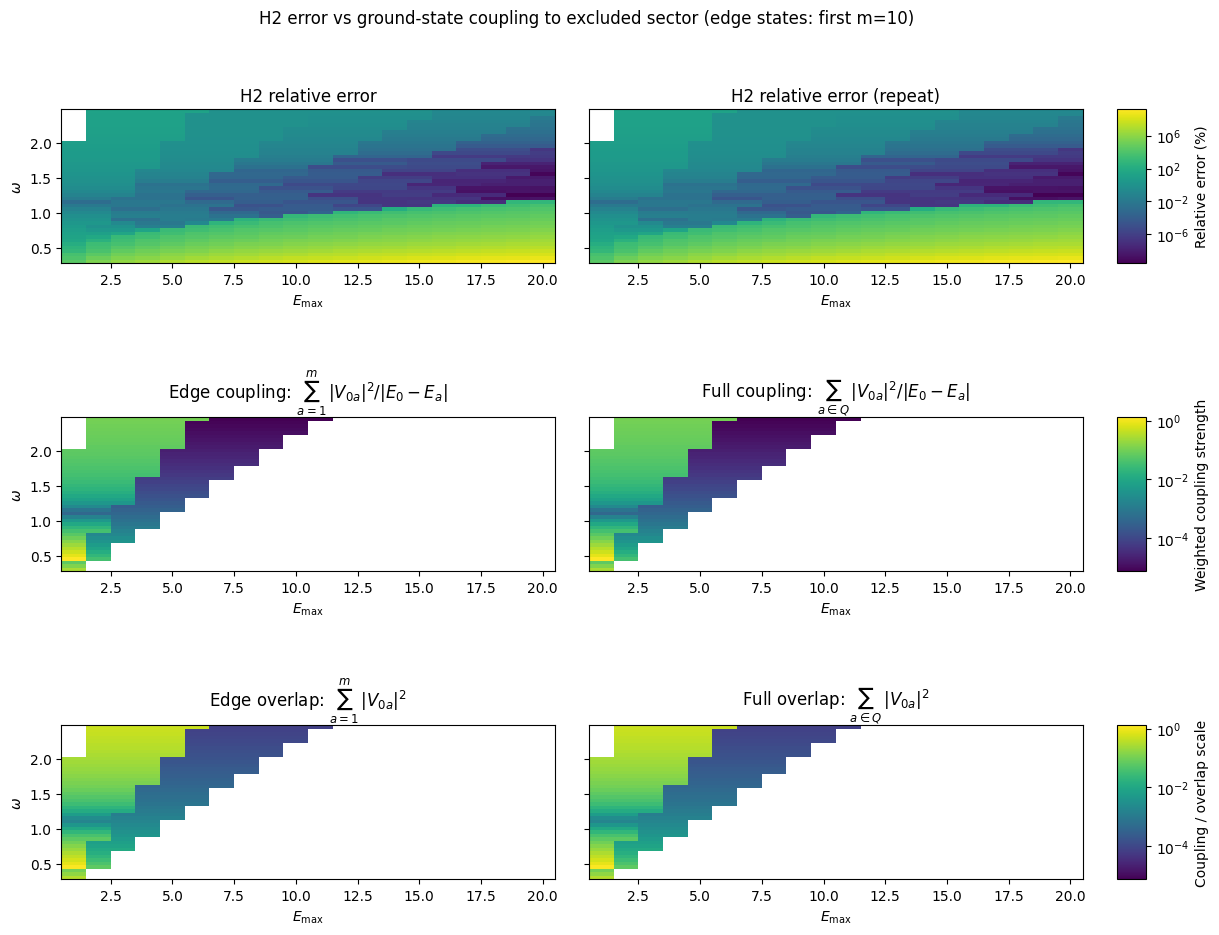

In [ ]:
def plot_htet_edge_coupling_diagnostics(scan):
    X = scan["Emax_list"]
    Y = scan["omega_list"]

    err_norm = _positive_log_norm(scan["H2_err"], floor=1e-24)
    edge_norm = _positive_log_norm(
        scan["edge_H2_weighted"],
        scan["edge_H2_unweighted"],
        scan["full_H2_weighted"],
        scan["full_H2_unweighted"],
        floor=1e-16
    )

    fig = plt.figure(figsize=(14, 10))
    gs = gridspec.GridSpec(3, 3, width_ratios=[1, 1, 0.06], hspace=1, wspace=0.10)

    # Top row: error map repeated for visual comparison
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.pcolormesh(X, Y, scan["H2_err"], shading="auto", norm=err_norm)
    ax1.set_title("H2 relative error")
    ax1.set_ylabel(r"$\omega$")
    ax1.set_xlabel(r"$E_{\max}$")

    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.pcolormesh(X, Y, scan["H2_err"], shading="auto", norm=err_norm)
    ax2.set_title("H2 relative error (repeat)")
    ax2.set_xlabel(r"$E_{\max}$")
    ax2.set_yticklabels([])

    cax1 = fig.add_subplot(gs[0, 2])
    cb1 = fig.colorbar(im2, cax=cax1)
    cb1.set_label("Relative error (%)")

    # Middle row: weighted couplings
    ax3 = fig.add_subplot(gs[1, 0])
    im3 = ax3.pcolormesh(X, Y, scan["edge_H2_weighted"], shading="auto", norm=edge_norm)
    ax3.set_title(r"Edge coupling: $\sum_{a=1}^{m}\, |V_{0a}|^2 / |E_0-E_a|$")
    ax3.set_ylabel(r"$\omega$")
    ax3.set_xlabel(r"$E_{\max}$")

    ax4 = fig.add_subplot(gs[1, 1])
    im4 = ax4.pcolormesh(X, Y, scan["full_H2_weighted"], shading="auto", norm=edge_norm)
    ax4.set_title(r"Full coupling: $\sum_{a\in Q}\, |V_{0a}|^2 / |E_0-E_a|$")
    ax4.set_xlabel(r"$E_{\max}$")
    ax4.set_yticklabels([])

    cax2 = fig.add_subplot(gs[1, 2])
    cb2 = fig.colorbar(im4, cax=cax2)
    cb2.set_label("Weighted coupling strength")

    # Bottom row: unweighted couplings
    ax5 = fig.add_subplot(gs[2, 0])
    im5 = ax5.pcolormesh(X, Y, scan["edge_H2_unweighted"], shading="auto", norm=edge_norm)
    ax5.set_title(r"Edge overlap: $\sum_{a=1}^{m}\, |V_{0a}|^2$")
    ax5.set_ylabel(r"$\omega$")
    ax5.set_xlabel(r"$E_{\max}$")

    ax6 = fig.add_subplot(gs[2, 1])
    im6 = ax6.pcolormesh(X, Y, scan["full_H2_unweighted"], shading="auto", norm=edge_norm)
    ax6.set_title(r"Full overlap: $\sum_{a\in Q}\, |V_{0a}|^2$")
    ax6.set_xlabel(r"$E_{\max}$")
    ax6.set_yticklabels([])

    cax3 = fig.add_subplot(gs[2, 2])
    cb3 = fig.colorbar(im6, cax=cax3)
    cb3.set_label("Coupling / overlap scale")

    plt.suptitle(
        f"H2 error vs ground-state coupling to excluded sector (edge states: first m={scan['m_edge']})",
        y=0.98
    )
    plt.tight_layout()
    plt.show()

plot_htet_edge_coupling_diagnostics(scan_edge)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
import mpmath as mp

def choose_N_uv(Emax, omega, extra=20):
    Emax = float(Emax)
    omega = float(omega)
    return max(int(np.floor(Emax / max(omega, 1e-12))) + extra, 40)


def edge_coupling_H2(V_PQ, EP, EQ, m=10, weighted=True):
    """
    Ground-state coupling to the first m excluded states above the cutoff.

    If weighted=True:
        sum_a |V_{0a}|^2 / |E0 - Ea|
    If weighted=False:
        sum_a |V_{0a}|^2
    """
    if len(EQ) == 0:
        return np.nan

    Ef = EP[0]
    m = min(m, len(EQ))
    s = 0.0

    for a in range(m):
        num = abs(complex(V_PQ[0, a]))**2
        if weighted:
            den = abs(float(Ef - EQ[a]))
            s += num / max(den, 1e-30)
        else:
            s += num

    return float(s)


def full_coupling_H2(V_PQ, EP, EQ, weighted=True):
    """
    Ground-state coupling to the full excluded sector.

    If weighted=True:
        sum_a |V_{0a}|^2 / |E0 - Ea|
    If weighted=False:
        sum_a |V_{0a}|^2
    """
    if len(EQ) == 0:
        return np.nan

    Ef = EP[0]
    s = 0.0

    for a in range(len(EQ)):
        num = abs(complex(V_PQ[0, a]))**2
        if weighted:
            den = abs(float(Ef - EQ[a]))
            s += num / max(den, 1e-30)
        else:
            s += num

    return float(s)


def scan_htet_edge_coupling_diagnostics(omega_list, Emax_list, lam, Known_E, m_edge=10):
    shape = (len(omega_list), len(Emax_list))

    H1_err = np.full(shape, np.nan)
    H2_err = np.full(shape, np.nan)
    H3_err = np.full(shape, np.nan)

    rel_H2 = np.full(shape, np.nan)
    rel_H3 = np.full(shape, np.nan)

    edge_H2_weighted   = np.full(shape, np.nan)
    edge_H2_unweighted = np.full(shape, np.nan)
    full_H2_weighted   = np.full(shape, np.nan)
    full_H2_unweighted = np.full(shape, np.nan)

    Pdim = np.full(shape, np.nan)
    Qdim = np.full(shape, np.nan)

    for j, Emax in enumerate(Emax_list):
        print(f"Scanning edge-coupling diagnostics: Emax = {Emax}")
        for i, omega in enumerate(omega_list):
            try:
                N_uv = choose_N_uv(Emax, omega, extra=20)

                omega_mp = mp.mpf(omega)
                lam_mp   = mp.mpf(lam)
                Emax_mp  = mp.mpf(Emax)

                # Build ingredients directly so V_PQ is accessible
                H0 = build_H0(N_uv, omega_mp)
                V  = build_V(N_uv, omega_mp, lam_mp)

                P, Q, En = indices_below_Emax(omega_mp, Emax_mp, N_uv)

                if len(P) == 0:
                    raise ValueError("P-space is empty.")
                if len(Q) == 0:
                    raise ValueError("Q-space is empty.")

                H0_PP = submatrix(H0, P, P)
                V_PP  = submatrix(V, P, P)
                V_PQ  = submatrix(V, P, Q)
                V_QP  = submatrix(V, Q, P)
                V_QQ  = submatrix(V, Q, Q)

                EP = [En[k] for k in P]
                EQ = [En[k] for k in Q]

                nP = len(P)
                nQ = len(Q)

                # ---------------- H1 ----------------
                H1_mat = H0_PP + V_PP

                # ---------------- dH2 ----------------
                dH2_mat = mp.matrix(nP, nP)
                for f in range(nP):
                    Ef = EP[f]
                    for k in range(nP):
                        s = mp.mpc("0")
                        for a in range(nQ):
                            s += V_PQ[f, a] * V_QP[a, k] / (Ef - EQ[a])
                        dH2_mat[f, k] = s

                H2_mat = H1_mat + dH2_mat

                # ---------------- dH3 ----------------
                dH3_mat = mp.matrix(nP, nP)
                for f in range(nP):
                    Ef = EP[f]
                    for k in range(nP):
                        # term 1
                        t1 = mp.mpc("0")
                        for a in range(nQ):
                            for b in range(nQ):
                                t1 += V_PQ[f, a] * V_QQ[a, b] * V_QP[b, k] / ((Ef - EQ[a]) * (Ef - EQ[b]))

                        # term 2
                        t2 = mp.mpc("0")
                        for a in range(nP):
                            for b in range(nQ):
                                t2 += V_PP[f, a] * V_PQ[a, b] * V_QP[b, k] / ((EP[a] - EQ[b]) * (Ef - EQ[b]))

                        dH3_mat[f, k] = t1 - t2

                H3_mat = H2_mat + dH3_mat

                # Convert for numerical diagnostics
                H1 = matrix_to_numpy(H1_mat)
                H2 = matrix_to_numpy(H2_mat)
                H3 = matrix_to_numpy(H3_mat)

                dH2 = H2 - H1
                dH3 = H3 - H2

                # Existing diagnostics
                rel_H2[i, j] = safe_rel_norm(dH2, H1)
                rel_H3[i, j] = safe_rel_norm(dH3, H1)

                Pdim[i, j] = len(P)
                Qdim[i, j] = len(Q)

                E1 = ground_state_energy_from_any_matrix(H1)
                E2 = ground_state_energy_from_any_matrix(H2)
                E3 = ground_state_energy_from_any_matrix(H3)

                H1_err[i, j] = 100.0 * abs((complex(E1) - complex(Known_E)) / complex(Known_E))
                H2_err[i, j] = 100.0 * abs((complex(E2) - complex(Known_E)) / complex(Known_E))
                H3_err[i, j] = 100.0 * abs((complex(E3) - complex(Known_E)) / complex(Known_E))

                # New edge-coupling diagnostics
                edge_H2_weighted[i, j] = edge_coupling_H2(V_PQ, EP, EQ, m=m_edge, weighted=True)
                edge_H2_unweighted[i, j] = edge_coupling_H2(V_PQ, EP, EQ, m=m_edge, weighted=False)
                full_H2_weighted[i, j] = full_coupling_H2(V_PQ, EP, EQ, weighted=True)
                full_H2_unweighted[i, j] = full_coupling_H2(V_PQ, EP, EQ, weighted=False)

            except Exception as e:
                print(f"  failed at Emax={Emax}, omega={omega}: {e}")

    return {
        "omega_list": np.array([float(x) for x in omega_list]),
        "Emax_list": np.array([float(x) for x in Emax_list]),
        "H1_err": H1_err,
        "H2_err": H2_err,
        "H3_err": H3_err,
        "rel_H2": rel_H2,
        "rel_H3": rel_H3,
        "edge_H2_weighted": edge_H2_weighted,
        "edge_H2_unweighted": edge_H2_unweighted,
        "full_H2_weighted": full_H2_weighted,
        "full_H2_unweighted": full_H2_unweighted,
        "Pdim": Pdim,
        "Qdim": Qdim,
        "m_edge": m_edge,
    }


def _positive_log_norm(*arrays, floor=1e-24):
    vals = np.concatenate([np.asarray(a).ravel() for a in arrays])
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size == 0:
        return colors.LogNorm(vmin=floor, vmax=1.0)
    return colors.LogNorm(vmin=max(vals.min(), floor), vmax=vals.max())


def plot_htet_edge_coupling_diagnostics(scan):
    X = scan["Emax_list"]
    Y = scan["omega_list"]

    err_norm = _positive_log_norm(scan["H2_err"], floor=1e-24)
    edge_norm = _positive_log_norm(
        scan["edge_H2_weighted"],
        scan["edge_H2_unweighted"],
        scan["full_H2_weighted"],
        scan["full_H2_unweighted"],
        floor=1e-16
    )

    fig = plt.figure(figsize=(14, 10))
    gs = gridspec.GridSpec(3, 3, width_ratios=[1, 1, 0.06], hspace=0.22, wspace=0.10)

    # Top row: error map repeated for visual comparison
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.pcolormesh(X, Y, scan["H2_err"], shading="auto", norm=err_norm)
    ax1.set_title("H2 relative error")
    ax1.set_ylabel(r"$\omega$")
    ax1.set_xlabel(r"$E_{\max}$")

    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.pcolormesh(X, Y, scan["H2_err"], shading="auto", norm=err_norm)
    ax2.set_title("H2 relative error (repeat)")
    ax2.set_xlabel(r"$E_{\max}$")
    ax2.set_yticklabels([])

    cax1 = fig.add_subplot(gs[0, 2])
    cb1 = fig.colorbar(im2, cax=cax1)
    cb1.set_label("Relative error (%)")

    # Middle row: weighted couplings
    ax3 = fig.add_subplot(gs[1, 0])
    im3 = ax3.pcolormesh(X, Y, scan["edge_H2_weighted"], shading="auto", norm=edge_norm)
    ax3.set_title(r"Edge coupling: $\sum_{a=1}^{m}\, |V_{0a}|^2 / |E_0-E_a|$")
    ax3.set_ylabel(r"$\omega$")
    ax3.set_xlabel(r"$E_{\max}$")

    ax4 = fig.add_subplot(gs[1, 1])
    im4 = ax4.pcolormesh(X, Y, scan["full_H2_weighted"], shading="auto", norm=edge_norm)
    ax4.set_title(r"Full coupling: $\sum_{a\in Q}\, |V_{0a}|^2 / |E_0-E_a|$")
    ax4.set_xlabel(r"$E_{\max}$")
    ax4.set_yticklabels([])

    cax2 = fig.add_subplot(gs[1, 2])
    cb2 = fig.colorbar(im4, cax=cax2)
    cb2.set_label("Weighted coupling strength")

    # Bottom row: unweighted couplings
    ax5 = fig.add_subplot(gs[2, 0])
    im5 = ax5.pcolormesh(X, Y, scan["edge_H2_unweighted"], shading="auto", norm=edge_norm)
    ax5.set_title(r"Edge overlap: $\sum_{a=1}^{m}\, |V_{0a}|^2$")
    ax5.set_ylabel(r"$\omega$")
    ax5.set_xlabel(r"$E_{\max}$")

    ax6 = fig.add_subplot(gs[2, 1])
    im6 = ax6.pcolormesh(X, Y, scan["full_H2_unweighted"], shading="auto", norm=edge_norm)
    ax6.set_title(r"Full overlap: $\sum_{a\in Q}\, |V_{0a}|^2$")
    ax6.set_xlabel(r"$E_{\max}$")
    ax6.set_yticklabels([])

    cax3 = fig.add_subplot(gs[2, 2])
    cb3 = fig.colorbar(im6, cax=cax3)
    cb3.set_label("Coupling / overlap scale")

    plt.suptitle(
        f"H2 error vs ground-state coupling to excluded sector (edge states: first m={scan['m_edge']})",
        y=0.98
    )
    plt.tight_layout()
    plt.show()


omega_list = [mp.mpf("0.3") + i * mp.mpf("0.05") for i in range(44)]   # 0.3 -> 2.7
Emax_list  = [mp.mpf("1") + i * mp.mpf("1") for i in range(79)]      # 8 -> 96
lam_scan = mp.mpf("1.0")
Known_E = mp.mpf("0.52773612731410831269035109114701621561393954399308")

scan_edge = scan_htet_edge_coupling_diagnostics(
    omega_list=omega_list,
    Emax_list=Emax_list,
    lam=lam_scan,
    Known_E=Known_E,
    m_edge=10   # try 5 or 10
)

plot_htet_edge_coupling_diagnostics(scan_edge)

Scanning edge-coupling diagnostics: Emax = 1.0
  failed at Emax=1.0, omega=2.05: P-space is empty.
  failed at Emax=1.0, omega=2.1: P-space is empty.
  failed at Emax=1.0, omega=2.15: P-space is empty.
  failed at Emax=1.0, omega=2.2: P-space is empty.
  failed at Emax=1.0, omega=2.25: P-space is empty.
  failed at Emax=1.0, omega=2.3: P-space is empty.
  failed at Emax=1.0, omega=2.35: P-space is empty.
  failed at Emax=1.0, omega=2.4: P-space is empty.
  failed at Emax=1.0, omega=2.45: P-space is empty.
Scanning edge-coupling diagnostics: Emax = 2.0
Scanning edge-coupling diagnostics: Emax = 3.0
Scanning edge-coupling diagnostics: Emax = 4.0
Scanning edge-coupling diagnostics: Emax = 5.0
Scanning edge-coupling diagnostics: Emax = 6.0
Scanning edge-coupling diagnostics: Emax = 7.0
Scanning edge-coupling diagnostics: Emax = 8.0
Scanning edge-coupling diagnostics: Emax = 9.0
Scanning edge-coupling diagnostics: Emax = 10.0
Scanning edge-coupling diagnostics: Emax = 11.0
Scanning edge-cou

KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mpmath as mp


lam_scan = mp.mpf("1.0")
Emax_fixed = mp.mpf("40.0")
omega_list = [mp.mpf("0.40") + i * mp.mpf("0.011") for i in range(100)]  # 0.50 to 1.40
E0 = mp.mpf("0.52773612731410831269035109114701621561393954399308")
hermitianize = False


def real_part_if_close(z, imag_tol=1e-12):
    z = mp.mpc(z)
    if abs(mp.im(z)) > imag_tol:
        print(f"Warning: eigenvalue has non-negligible imaginary part: {z}")
    return mp.re(z)


def relative_error_percent(E_num, E_exact):
    E_num = mp.mpf(E_num)
    E_exact = mp.mpf(E_exact)
    err = abs((E_num - E_exact) / E_exact) * 100
    return float(err)

def choose_N_uv(Emax, omega):
    Emax = mp.mpf(Emax)
    omega = mp.mpf(omega)

    val = max(2 * Emax, Emax / omega)
    return int(mp.ceil(val))


def crossing_omegas(Emax, omega_min, omega_max, n_max=2000):
    """
    Return all omega in [omega_min, omega_max] where the HO truncation boundary changes:
        Emax = omega (n + 1/2)
    =>  omega = Emax / (n + 1/2)
    """
    vals = []
    for n in range(n_max + 1):
        w = float(Emax / (mp.mpf(n) + mp.mpf("0.5")))
        if omega_min <= w <= omega_max:
            vals.append((n, w))
    vals.sort(key=lambda t: t[1])
    return vals


def safe_positive(arr, floor=1e-300):
    arr = np.asarray(arr, dtype=float).copy()
    bad = ~np.isfinite(arr) | (arr <= 0)
    arr[bad] = floor
    return arr


def all_Heff_orders(N_uv, omega, lam, Emax, hermitianize=False):



    H0 = build_H0(N_uv, omega)
    V = build_V(N_uv, omega, lam)

    P, Q, En = indices_below_Emax(omega, Emax, N_uv)
    nP = len(P)
    nQ = len(Q)

    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")

    H0_PP = submatrix(H0, P, P)
    V_PP  = submatrix(V, P, P)

    V_PQ = submatrix(V, P, Q) if nQ > 0 else mp.matrix(nP, 0)
    V_QP = submatrix(V, Q, P) if nQ > 0 else mp.matrix(0, nP)
    V_QQ = submatrix(V, Q, Q) if nQ > 0 else mp.matrix(0, 0)

    EP = [En[i] for i in P]
    EQ = [En[i] for i in Q]


    H1 = H0_PP + V_PP

    if nQ == 0:
        H2 = mp.matrix(H1)
        H3 = mp.matrix(H1)
        if hermitianize:
            H1 = hermitize(H1)
            H2 = hermitize(H2)
            H3 = hermitize(H3)
        return H1, H2, H3, P, Q, H0, V

    DeltaH2 = mp.matrix(nP, nP)

    for f in range(nP):
        Ef = EP[f]
        inv_f = [1 / (Ef - Eqa) for Eqa in EQ]
        for i in range(nP):
            s = mp.mpc("0")
            for a in range(nQ):
                s += V_PQ[f, a] * inv_f[a] * V_QP[a, i]
            DeltaH2[f, i] = s

    H2 = H1 + DeltaH2

    DeltaH3 = mp.matrix(nP, nP)

    # A[a,b] = V_PQ[a,b] / (E_P[a] - E_Q[b])
    A = mp.matrix(nP, nQ)
    for a in range(nP):
        for b in range(nQ):
            A[a, b] = V_PQ[a, b] / (EP[a] - EQ[b])

    for f in range(nP):
        Ef = EP[f]
        inv_f = [1 / (Ef - Eqa) for Eqa in EQ]

        # First term:
        # sum_{a,b in Q} V_fa V_ab V_bi / [(Ef-Ea)(Ef-Eb)]
        tmp_b = [mp.mpc("0") for _ in range(nQ)]
        for b in range(nQ):
            s = mp.mpc("0")
            for a in range(nQ):
                s += V_PQ[f, a] * inv_f[a] * V_QQ[a, b]
            tmp_b[b] = s

        term1_row = [mp.mpc("0") for _ in range(nP)]
        for i in range(nP):
            s = mp.mpc("0")
            for b in range(nQ):
                s += tmp_b[b] * inv_f[b] * V_QP[b, i]
            term1_row[i] = s

        # Second term:
        # sum_{a in P, b in Q} V_fa V_ab V_bi / [(Ea-Eb)(Ef-Eb)]
        s_b = [mp.mpc("0") for _ in range(nQ)]
        for b in range(nQ):
            s = mp.mpc("0")
            for a in range(nP):
                s += V_PP[f, a] * A[a, b]
            s_b[b] = s

        term2_row = [mp.mpc("0") for _ in range(nP)]
        for i in range(nP):
            s = mp.mpc("0")
            for b in range(nQ):
                s += s_b[b] * inv_f[b] * V_QP[b, i]
            term2_row[i] = s

        for i in range(nP):
            DeltaH3[f, i] = term1_row[i] - term2_row[i]

    H3 = H2 + DeltaH3

    if hermitianize:
        H1 = hermitize(H1)
        H2 = hermitize(H2)
        H3 = hermitize(H3)

    return H1, H2, H3, P, Q, H0, V



omega_vals = []
err_H1 = []
err_H2 = []
err_H3 = []
n_ret_vals = []

i = 0
for omega in omega_list:
    try:
        N_uv = choose_N_uv(Emax_fixed,omega)

        H1, H2, H3, P, Q, H0_full, V_full = all_Heff_orders(
            N_uv=N_uv,
            omega=omega,
            lam=lam_scan,
            Emax=Emax_fixed,
            hermitianize=hermitianize
        )

        # H1 should be treated as Hermitian
        E1, _ = ground_state_energy_from_matrix(H1, hermitian=True)

        # H2/H3 follow chosen setting
        if hermitianize:
            E2, _ = ground_state_energy_from_matrix(H2, hermitian=True)
            E3, _ = ground_state_energy_from_matrix(H3, hermitian=True)
        else:
            E2, _ = ground_state_energy_from_matrix(H2, hermitian=False)
            E3, _ = ground_state_energy_from_matrix(H3, hermitian=False)

        E1r = real_part_if_close(E1)
        E2r = real_part_if_close(E2)
        E3r = real_part_if_close(E3)

        omega_vals.append(float(omega))
        err_H1.append(relative_error_percent(E1r, E0))
        err_H2.append(relative_error_percent(E2r, E0))
        err_H3.append(relative_error_percent(E3r, E0))
        n_ret_vals.append(len(P))

        i+=1
        print(i)

    except Exception as e:
        print(f"Skipping omega={omega}: {e}")


omega_vals = np.array(omega_vals, dtype=float)
err_H1 = np.array(err_H1, dtype=float)
err_H2 = np.array(err_H2, dtype=float)
err_H3 = np.array(err_H3, dtype=float)
n_ret_vals = np.array(n_ret_vals, dtype=int)

if len(omega_vals) == 0:
    raise RuntimeError("No valid data points were computed.")


omega_min = float(np.min(omega_vals))
omega_max = float(np.max(omega_vals))
crossings = crossing_omegas(Emax_fixed, omega_min, omega_max, n_max=4000)

print(f"Fixed Emax = {float(Emax_fixed)}")
print(f"Computed {len(omega_vals)} omega points.")
print(f"Found {len(crossings)} HO boundary-crossing lines in plot range.")
print("First few crossings:")
for n, w in crossings[:15]:
    print(f"  n = {n:3d}, omega_cross = {w:.6f}")



err_H1_plot = safe_positive(err_H1)
err_H2_plot = safe_positive(err_H2)
err_H3_plot = safe_positive(err_H3)



1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
Fixed Emax = 40.0
Computed 100 omega points.
Found 73 HO boundary-crossing lines in plot range.
First few crossings:
  n =  99, omega_cross = 0.402010
  n =  98, omega_cross = 0.406091
  n =  97, omega_cross = 0.410256
  n =  96, omega_cross = 0.414508
  n =  95, omega_cross = 0.418848
  n =  94, omega_cross = 0.423280
  n =  93, omega_cross = 0.427807
  n =  92, omega_cross = 0.432432
  n =  91, omega_cross = 0.437158
  n =  90, omega_cross = 0.441989
  n =  89, omega_cross = 0.446927
  n =  88, omega_cross = 0.451977
  n =  87, omega_cross = 0.457143
  n =  86, omega_cross = 0.462428
  n =  85, omega_cross = 0.467836


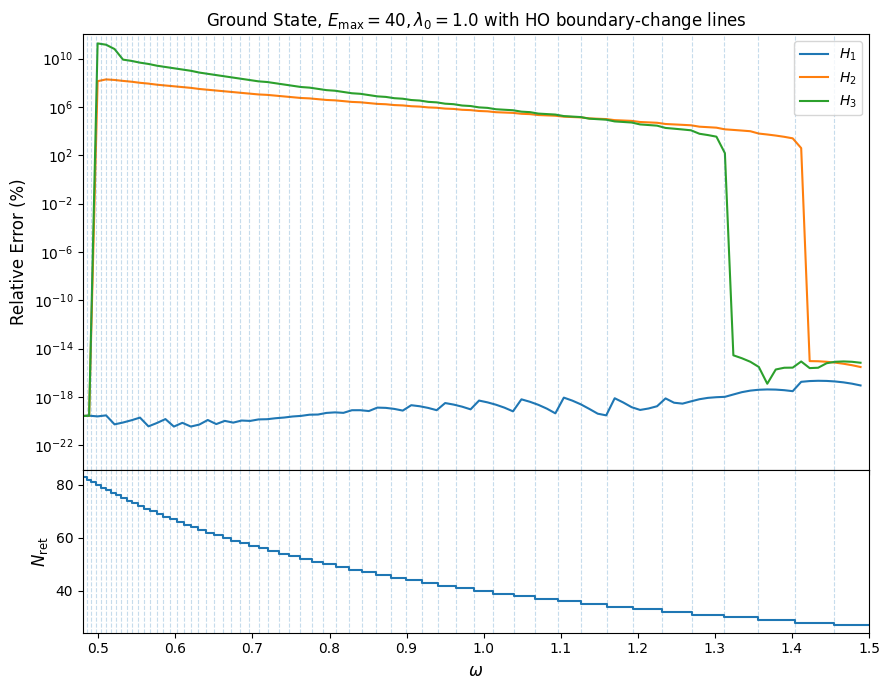

In [84]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1.2], "hspace": 0}
)

omega_min, omega_max = 0.48, 1.5

# Top panel: error curves
ax1.semilogy(omega_vals, err_H1_plot, label=r"$H_1$")
ax1.semilogy(omega_vals, err_H2_plot, label=r"$H_2$")
ax1.semilogy(omega_vals, err_H3_plot, label=r"$H_3$")

for n, w in crossings:
    if omega_min <= w <= omega_max:
        ax1.axvline(w, linestyle="--", alpha=0.25, linewidth=0.8)

ax1.set_ylabel("Relative Error (%)", fontsize=fontsize)
ax1.set_title(
    rf"Ground State, $E_{{\max}} = {float(Emax_fixed):.0f}, \lambda_0 = 1.0$ with HO boundary-change lines", fontsize=fontsize
)
ax1.set_xlim(omega_min, omega_max)
ax1.set_ylim(1e-24, 1e12)
ax1.legend()

ticksx = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
ax1.set_xticks(ticksx)
ax1.xaxis.set_minor_locator(mticker.NullLocator())
ax1.set_xticklabels([f"{t:.1f}" for t in ticksx])

ticksy = [1e-22,1e-18,1e-14,1e-10,1e-6,1e-2,1e2,1e6,1e10]
ax1.set_yticks(ticksy)
ax1.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax1.yaxis.set_minor_locator(mticker.NullLocator())

# Bottom panel: exact staircase aligned with crossings
x_step = [omega_min] + [w for _, w in crossings if omega_min <= w <= omega_max] + [omega_max]
x_step = sorted(set(x_step))

y_step = []
for j in range(len(x_step) - 1):
    w_mid = 0.5 * (x_step[j] + x_step[j + 1])
    N_mid = int(np.floor(float(Emax_fixed) / w_mid + 0.5))
    y_step.append(N_mid)
y_step.append(y_step[-1])

ax2.step(x_step, y_step, where="post")
for n, w in crossings:
    if omega_min <= w <= omega_max:
        ax2.axvline(w, linestyle="--", alpha=0.25, linewidth=0.8)

ax2.set_xlabel(r"$\omega$", fontsize=fontsize)
ax2.set_ylabel(r"$N_{\rm ret}$", fontsize=fontsize)
ax2.set_xlim(omega_min, omega_max)

if max(y_step) - min(y_step) <= 25:
    ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()